In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Robust analysis of CLADES - Random seeds (Cord blood)

In [7]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans')

In [8]:
model_list = []

for name in tqdm(os.listdir("../trials/revision_1_nni/checkpoints/CBRandomSeed")):
    if os.path.exists(f'../trials/revision_1_nni/checkpoints/CBRandomSeed/{name}/model_last.pt'):
        gpu_id = 1
        temp = torch.load(f'../trials/revision_1_nni/checkpoints/CBRandomSeed/{name}/model_last.pt', map_location=f'cuda:{gpu_id}')
        temp.model.block.clipping = False

        model_list.append(temp)
        model_list[-1].config['system']['gpu_id'] = gpu_id

  0%|          | 0/51 [00:00<?, ?it/s]

100%|██████████| 51/51 [00:00<00:00, 164.73it/s]


In [9]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans')

In [10]:
from clonaltrans.utils import get_K_total

model_Ks = []
for model in tqdm(model_list):
    model_Ks.append(get_K_total(model))

model_Ks = np.stack(model_Ks)

  0%|          | 0/48 [00:00<?, ?it/s]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 48/48 [04:13<00:00,  5.28s/it]


In [11]:
model_Ks.shape

(48, 18, 13, 12, 12)

In [12]:
index = pd.read_csv('./datasets/CordBlood_Refine/data/graph_table.csv', index_col=0).values
np.fill_diagonal(index, 1)
indices = np.argwhere(index == 1)
filtered_model_Ks = model_Ks[:, :, :, indices[:, 0], indices[:, 1]]

In [13]:
filtered_model_Ks.shape

(48, 18, 13, 25)

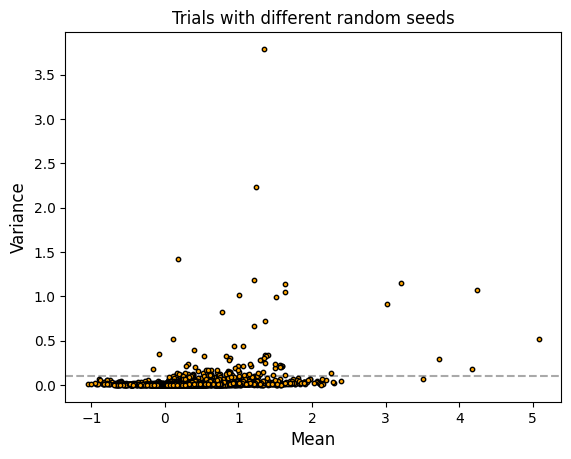

In [14]:
reshaped_Ks = filtered_model_Ks.reshape(filtered_model_Ks.shape[0], -1)
mean_cols = np.mean(reshaped_Ks, axis=0)
variance_cols = np.var(reshaped_Ks, axis=0)

plt.scatter(mean_cols, variance_cols, s=10, edgecolors='black', c='orange', zorder=2)
plt.title('Trials with different random seeds', fontsize=12)
plt.xlabel('Mean', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.grid(False)
plt.axhline(0.1, -1, 5, color='#A9A9A9', linestyle='dashed', zorder=1)
plt.savefig('Reviewer1_Q7d_2.svg', dpi=300, bbox_inches='tight', transparent=True)

### Robust analysis of CLADES - Reproducibility (Cord blood)

In [15]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans')

In [16]:
model_list = []

for name in tqdm(os.listdir("../trials/revision_1_nni/checkpoints/CBFixEverything")):
    if os.path.exists(f'../trials/revision_1_nni/checkpoints/CBFixEverything/{name}/model_last.pt'):
        gpu_id = 1
        temp = torch.load(f'../trials/revision_1_nni/checkpoints/CBFixEverything/{name}/model_last.pt', map_location=f'cuda:{gpu_id}')
        temp.model.block.clipping = False

        model_list.append(temp)
        model_list[-1].config['system']['gpu_id'] = gpu_id

100%|██████████| 51/51 [00:00<00:00, 109.32it/s]


In [17]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans')

In [18]:
from clonaltrans.utils import get_K_total

model_Ks = []
for model in tqdm(model_list):
    model_Ks.append(get_K_total(model))

model_Ks = np.stack(model_Ks)

  0%|          | 0/39 [00:00<?, ?it/s]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 39/39 [03:45<00:00,  5.79s/it]


In [19]:
model_Ks.shape

(39, 18, 13, 12, 12)

In [20]:
index = pd.read_csv('./datasets/CordBlood_Refine/data/graph_table.csv', index_col=0).values
np.fill_diagonal(index, 1)
indices = np.argwhere(index == 1)
filtered_model_Ks = model_Ks[:, :, :, indices[:, 0], indices[:, 1]]

In [21]:
filtered_model_Ks.shape

(39, 18, 13, 25)

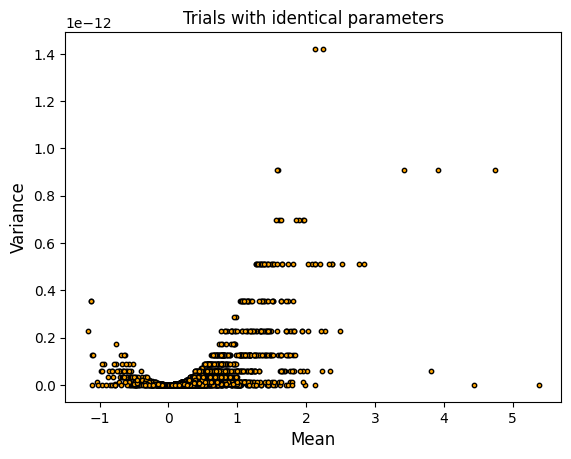

In [22]:
reshaped_Ks = filtered_model_Ks.reshape(filtered_model_Ks.shape[0], -1)
mean_cols = np.mean(reshaped_Ks, axis=0)
variance_cols = np.var(reshaped_Ks, axis=0)

plt.scatter(mean_cols, variance_cols, s=10, edgecolors='black', c='orange')
plt.title('Trials with identical parameters', fontsize=12)
plt.xlabel('Mean', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.grid(False)
plt.savefig('Reviewer1_Q7d_1.svg', dpi=300, bbox_inches='tight', transparent=True)

### Robust analysis of CLADES - Coefficient of penalties (Mouse hematopoiesis)

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans')

In [3]:
model_list = []

for name in tqdm(os.listdir("../trials/revision_1_nni/checkpoints/WRAlphas")):
    if os.path.exists(f'../trials/revision_1_nni/checkpoints/WRAlphas/{name}/model_last.pt'):
        gpu_id = 1
        temp = torch.load(f'../trials/revision_1_nni/checkpoints/WRAlphas/{name}/model_last.pt', map_location=f'cuda:{gpu_id}')
        temp.model.block.clipping = False

        model_list.append(temp)
        model_list[-1].config['system']['gpu_id'] = gpu_id

  0%|          | 0/301 [00:00<?, ?it/s]

100%|██████████| 301/301 [00:02<00:00, 110.22it/s]


In [4]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans')

In [5]:
from clonaltrans.utils import get_K_total

model_Ks = []
for model in tqdm(model_list):
    model_Ks.append(get_K_total(model))

model_Ks = np.stack(model_Ks)

  0%|          | 0/250 [00:00<?, ?it/s]

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 250/250 [06:59<00:00,  1.68s/it]


In [6]:
model_Ks.shape

(250, 7, 14, 22, 22)

In [7]:
index = pd.read_csv('./datasets/Weinreb/data/graph_table.csv', index_col=0).values
np.fill_diagonal(index, 1)
indices = np.argwhere(index == 1)
filtered_model_Ks = model_Ks[:, :, :, indices[:, 0], indices[:, 1]]

In [8]:
filtered_model_Ks.shape

(250, 7, 14, 44)

In [9]:
7*14*44

4312

In [13]:
np.sum(variance_cols <= 1)

4252

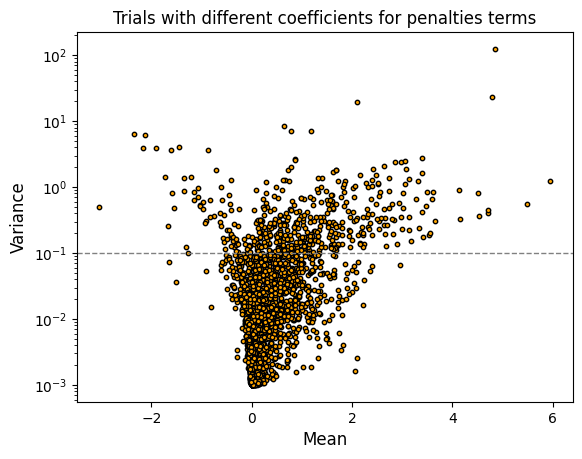

In [11]:
reshaped_Ks = filtered_model_Ks.reshape(filtered_model_Ks.shape[0], -1)
mean_cols = np.mean(reshaped_Ks, axis=0)
variance_cols = np.var(reshaped_Ks, axis=0)

plt.scatter(mean_cols, variance_cols + 1e-3, s=10, edgecolors='black', c='orange')
plt.title('Trials with different coefficients for penalties terms', fontsize=12)
plt.xlabel('Mean', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.grid(False)
plt.yscale('log')

ax = plt.gca()
ax.axhline(1e-1, color='grey', linewidth=1, zorder=1, linestyle='dashed')

# plt.savefig('Reviewer1_Q7a_2.svg', dpi=300, bbox_inches='tight', transparent=True)

### Individual clones making up each meta-clone (Cord blood)

In [3]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans')

In [4]:
adata_cb = sc.read_h5ad('./datasets/Human_CordBlood/adata_update.h5ad')
adata_wr = sc.read_h5ad('./datasets/Mouse_Hematopoiesis/klein_update.h5ad')

In [5]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
          '#bcbd22', '#17becf', '#7fcdbb', '#edf8b1', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0',
          '#225ea8', '#253494', '#081d58', '#393b79', '#5254a3', '#6b6ecf', '#9c9ede', '#637939']

In [103]:
# adata_cb = adata_cb[adata_cb.obs['Timepoint'] == 'Day17']

In [12]:
info_cb = adata_cb.obs[['Meta clones', 'clones', 'def_lab']]
info_cb = info_cb[info_cb['Meta clones'] != "-1.0"]
info_cb['combined'] = 'Meta_' + info_cb['Meta clones'].astype(str) + '_' + info_cb['clones'].astype(str)
info_cb = info_cb.sort_values(by='combined')
info_cb['color'] = [colors[int(i)] for i in info_cb['Meta clones']]
info_cb

,Meta clones,clones,def_lab,combined,color
SITTC9CTTTCAACAGGTATGG,0,Clone_106,Mast cell,Meta_0_Clone_106,#1f77b4
SITTB5AACAGGGGTTAGGACG,0,Clone_106,Early Erythroid,Meta_0_Clone_106,#1f77b4
SITTC9GGGCTACCAGACAAGC,0,Clone_106,Mid Erythroid,Meta_0_Clone_106,#1f77b4
SITTB5AGTCTCCTCAACTGGT,0,Clone_106,Early Erythroid,Meta_0_Clone_106,#1f77b4
SITTC9ATTTACCGTGGCGCTT,0,Clone_106,Mast cell,Meta_0_Clone_106,#1f77b4
...,...,...,...,...,...
SITTG7GAGACTTTCCAGGACC,9,Clone_3883,Mast cell,Meta_9_Clone_3883,#17becf
SITTG7GTAGTACCACGAGGAT,9,Clone_3883,Mast cell,Meta_9_Clone_3883,#17becf
SITTG7AGGGTGAGTCACAATC,9,Clone_532,Mast cell,Meta_9_Clone_532,#17becf
SITTG7GATCATGCACAACATC,9,Clone_532,Mast cell,Meta_9_Clone_532,#17becf


In [13]:
pivot_table = pd.crosstab(info_cb['combined'], info_cb['def_lab'])
pivot_table = pivot_table[["HSC/MPP 1", "HSC/MPP 2", "MEMP", "Mast cell", "Early Erythroid", "Mid Erythroid" , "Late Erythroid", "NMP", "Mono precur", "Monocyte", "DC precursor", "DC"]]
# pivot_table = pivot_table[["HSC/MPP 1", "HSC/MPP 2", "MEMP", "Mast cell", "Early Erythroid", "NMP", "Mono precur", "Monocyte"]]
# pivot_table = pivot_table[["HSC/MPP 2", "MEMP", "Mast cell", "Early Erythroid", "Mid Erythroid" , "Late Erythroid", "NMP", "Mono precur", "Monocyte", "DC precursor", "DC"]]
pivot_table = pivot_table.loc[natsorted(pivot_table.index)]
pivot_table

def_lab,HSC/MPP 1,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
combined,,,,,,,,,,,,
Meta_0_Clone_23,0,0,0,5,12,9,0,0,0,1,0,0
Meta_0_Clone_59,0,1,0,14,0,0,0,1,0,7,0,0
Meta_0_Clone_66,0,0,0,11,8,1,3,0,0,0,0,0
Meta_0_Clone_106,0,0,0,4,6,6,2,0,0,1,0,0
Meta_0_Clone_180,0,0,0,8,10,4,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
Meta_11_Clone_3199,0,0,0,0,3,0,0,0,0,0,0,0
Meta_11_Clone_3204,0,0,1,0,2,0,0,0,0,0,0,0
Meta_11_Clone_3358,0,0,0,0,4,0,0,0,0,0,0,0


In [14]:
pivot_table[pivot_table == 0] = 0.5
pivot_table = np.log2(pivot_table)
pivot_table[pivot_table == -1] = 0
pivot_table

/tmp/ipykernel_1753100/3565897442.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pivot_table[pivot_table == 0] = 0.5


def_lab,HSC/MPP 1,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
combined,,,,,,,,,,,,
Meta_0_Clone_23,0.0,0.0,0.0,2.321928,3.584963,3.169925,0.000000,0.0,0.0,0.000000,0.0,0.0
Meta_0_Clone_59,0.0,0.0,0.0,3.807355,0.000000,0.000000,0.000000,0.0,0.0,2.807355,0.0,0.0
Meta_0_Clone_66,0.0,0.0,0.0,3.459432,3.000000,0.000000,1.584963,0.0,0.0,0.000000,0.0,0.0
Meta_0_Clone_106,0.0,0.0,0.0,2.000000,2.584963,2.584963,1.000000,0.0,0.0,0.000000,0.0,0.0
Meta_0_Clone_180,0.0,0.0,0.0,3.000000,3.321928,2.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
Meta_11_Clone_3199,0.0,0.0,0.0,0.000000,1.584963,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
Meta_11_Clone_3204,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
Meta_11_Clone_3358,0.0,0.0,0.0,0.000000,2.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0


In [15]:
elements = [i.split('_')[1] for i in list(pivot_table.index)]
start_positions = {element: len(elements) - i for i, element in enumerate(reversed(elements), 1)}
start_positions

{'11': 590,
 '10': 569,
 '9': 535,
 '8': 496,
 '7': 452,
 '6': 406,
 '5': 357,
 '4': 299,
 '3': 233,
 '2': 167,
 '1': 94,
 '0': 0}

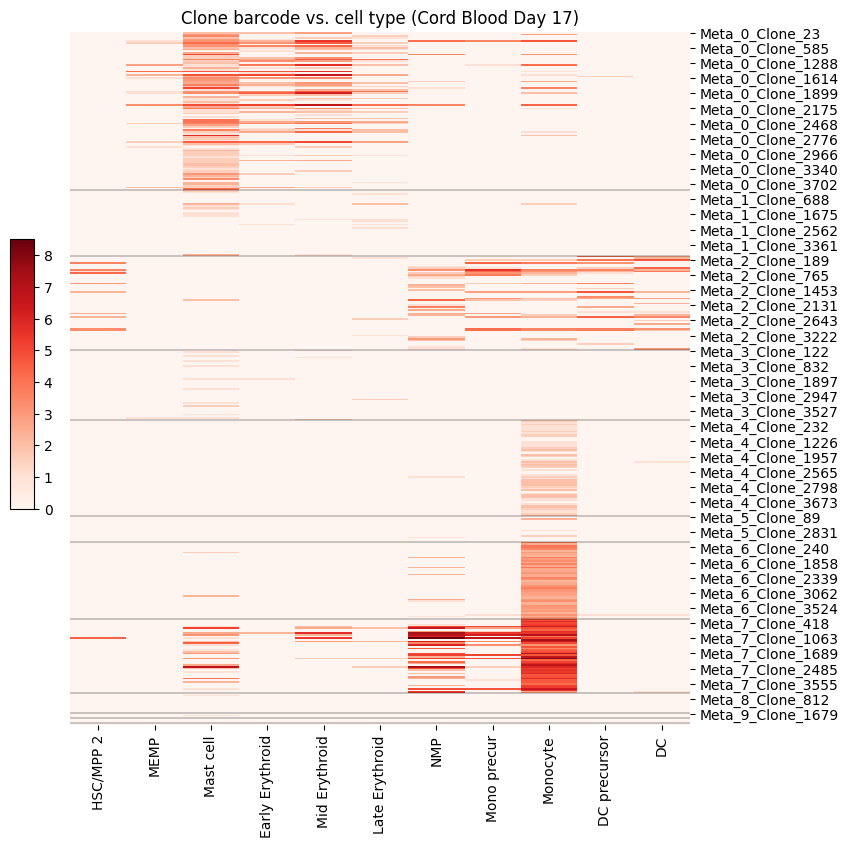

In [110]:
plt.figure(figsize=(8, 9))

ax = sns.heatmap(
    pivot_table, 
    cmap='Reds', 
    annot=False,
    cbar=False
)
ax.yaxis.tick_right()
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

cbar_ax = ax.figure.add_axes([0.05, 0.35, 0.03, 0.3])  # x, y, width, height
cbar = ax.figure.colorbar(ax.collections[0], cax=cbar_ax)

for pos in start_positions.keys():
    if pos == '0':
        pass
    else:
        ax.axhline(start_positions[pos], color='black', linewidth=0.3)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Clone barcode vs. cell type (Cord Blood Day 17)')
plt.savefig(f'./Reviewer1_Q6_5.svg', dpi=600, bbox_inches='tight', transparent=True)

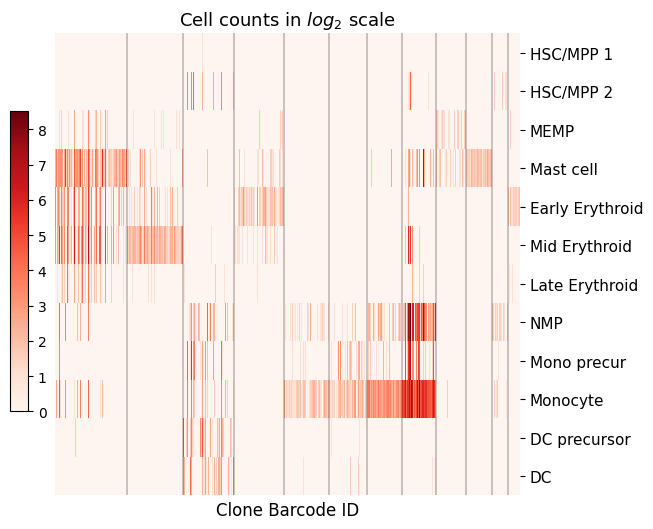

In [45]:
plt.figure(figsize=(6, 6))

ax = sns.heatmap(
    pivot_table.T, 
    cmap='Reds', 
    annot=False,
    cbar=False
)
ax.yaxis.tick_right()
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_xticklabels('')

ax.set_xticks([])
ax.set_xticklabels([])

cbar_ax = ax.figure.add_axes([0.05, 0.25, 0.03, 0.5])  # x, y, width, height
cbar = ax.figure.colorbar(ax.collections[0], cax=cbar_ax)

for pos in start_positions.keys():
    if pos == '0':
        pass
    else:
        ax.axvline(start_positions[pos], color='black', linewidth=0.3)

ax.set_xlabel('Clone Barcode ID', fontsize=12)
ax.set_ylabel('')
ax.set_title('Cell counts in $\it{log_2}$ scale', fontsize=13)
plt.savefig(f'./Reviewer1_Q6_9.svg', dpi=300, bbox_inches='tight', transparent=True)

### Individual clones making up each meta-clone (Mouse hematopoiesis)

In [134]:
adata_cb = sc.read_h5ad('./datasets/Human_CordBlood/adata_update.h5ad')
adata_wr = sc.read_h5ad('./datasets/Mouse_Hematopoiesis/klein_update.h5ad')

In [135]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
          '#bcbd22', '#17becf', '#7fcdbb', '#edf8b1', '#c7e9b4', '#7fcdbb', '#41b6c4', '#1d91c0',
          '#225ea8', '#253494', '#081d58', '#393b79', '#5254a3', '#6b6ecf', '#9c9ede', '#637939']

In [136]:
adata_wr = adata_wr[adata_wr.obs['Time_point'] == '6.0']

In [137]:
info_wr = adata_wr.obs[['Meta clones', 'clones', 'label_man']]
info_wr = info_wr[info_wr['Meta clones'] != "-1.0"]
info_wr['combined'] = 'Meta_' + info_wr['Meta clones'].astype(str) + '_' + info_wr['clones'].astype(str)
info_wr = info_wr.sort_values(by='combined')
info_wr['color'] = [colors[int(i)] for i in info_wr['Meta clones']]
info_wr

,Meta clones,clones,label_man,combined,color
78710,0,Clone_1003,prog_Mono,Meta_0_Clone_1003,#1f77b4
75692,0,Clone_1003,prog_Mono,Meta_0_Clone_1003,#1f77b4
70053,0,Clone_1003,prog_Neu,Meta_0_Clone_1003,#1f77b4
72754,0,Clone_1003,prog_Mono,Meta_0_Clone_1003,#1f77b4
130814,0,Clone_1013,prog_4,Meta_0_Clone_1013,#1f77b4
...,...,...,...,...,...
76466,9,Clone_841,DC,Meta_9_Clone_841,#17becf
73482,9,Clone_841,Mono,Meta_9_Clone_841,#17becf
76850,9,Clone_841,prog_DC_Mono,Meta_9_Clone_841,#17becf
73001,9,Clone_841,Mono,Meta_9_Clone_841,#17becf


In [138]:
pivot_table = pd.crosstab(info_wr['combined'], info_wr['label_man'])
graph = pd.read_excel('./datasets/Weinreb/mingze_weinreb.xlsx', index_col=0)
pops = graph.columns
# pops = ['prog_1', 'prog_2', 'prog_3', 'prog_4', 'prog_Baso_Meg_Ery_Mast',
#        'prog_Baso_Eos', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery',
#        'prog_Mono', 'early_prog_Neu', 'prog_Neu', 'Baso', 'DC', 'Ery',
#        'Mast', 'Meg', 'Mono']
pivot_table = pivot_table[pops]
pivot_table = pivot_table.loc[natsorted(pivot_table.index)]
pivot_table

label_man,prog_1,prog_2,prog_3,prog_4,prog_Baso_Meg_Ery_Mast,prog_Baso_Eos,prog_DC_Mono,prog_Ly_pDC,prog_Meg_Ery,prog_Mono,...,Baso,DC,Eos,Ery,Ly,Mast,Meg,Mono,Neu,pDC
combined,,,,,,,,,,,,,,,,,,,,,
Meta_0_Clone_5,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
Meta_0_Clone_18,0,4,3,3,0,0,0,0,0,8,...,0,0,0,0,0,0,0,0,0,0
Meta_0_Clone_21,0,1,0,2,0,0,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
Meta_0_Clone_23,0,0,0,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
Meta_0_Clone_25,0,0,0,0,0,0,0,0,0,12,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Meta_10_Clone_5774,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
Meta_10_Clone_5811,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
Meta_10_Clone_5820,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,0,0,0


In [139]:
pivot_table[pivot_table == 0] = 0.5
pivot_table = np.log2(pivot_table)
pivot_table[pivot_table == -1] = 0
pivot_table

/tmp/ipykernel_2501770/3565897442.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pivot_table[pivot_table == 0] = 0.5


label_man,prog_1,prog_2,prog_3,prog_4,prog_Baso_Meg_Ery_Mast,prog_Baso_Eos,prog_DC_Mono,prog_Ly_pDC,prog_Meg_Ery,prog_Mono,...,Baso,DC,Eos,Ery,Ly,Mast,Meg,Mono,Neu,pDC
combined,,,,,,,,,,,,,,,,,,,,,
Meta_0_Clone_5,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Meta_0_Clone_18,0.0,2.0,1.584963,1.584963,0.0,0.0,0.0,0.0,0.0,3.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Meta_0_Clone_21,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0,0.0,2.807355,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Meta_0_Clone_23,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.584963,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
Meta_0_Clone_25,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,3.584963,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Meta_10_Clone_5774,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
Meta_10_Clone_5811,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
Meta_10_Clone_5820,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,1.584963,0.0,0.0,0.0,0.0


In [140]:
elements = [i.split('_')[1] for i in list(pivot_table.index)]
start_positions = {element: len(elements) - i for i, element in enumerate(reversed(elements), 1)}
start_positions

{'12': 3359,
 '11': 3358,
 '10': 3250,
 '9': 3161,
 '8': 2966,
 '7': 2826,
 '6': 2733,
 '5': 2396,
 '4': 2059,
 '3': 1753,
 '2': 1278,
 '1': 668,
 '0': 0}

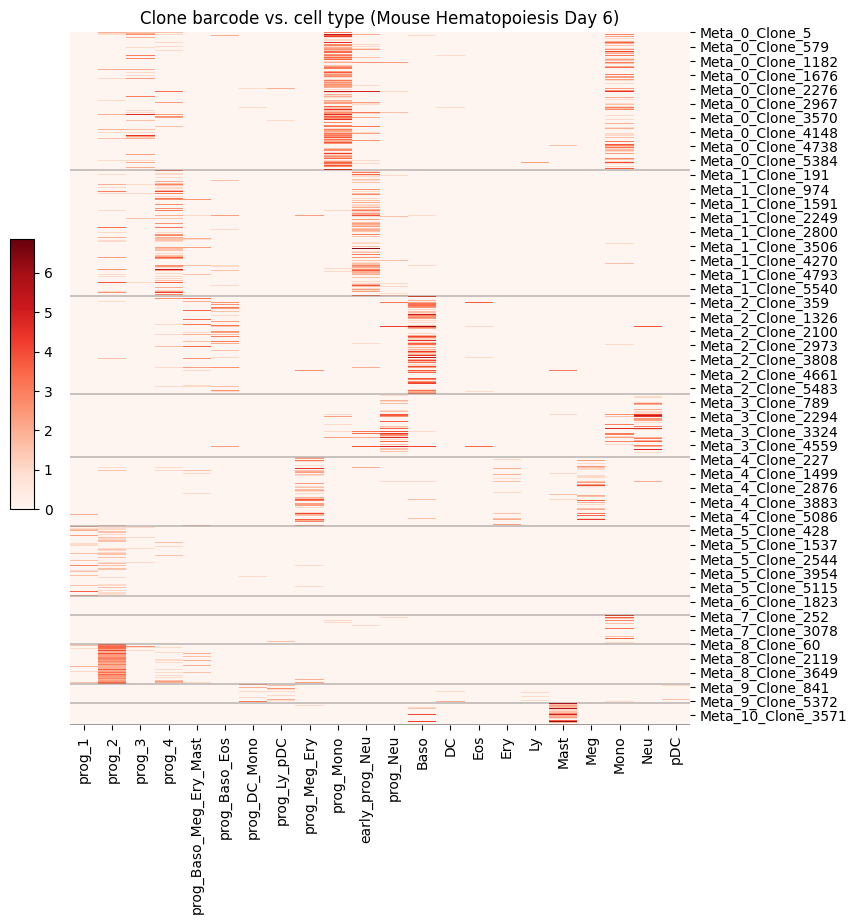

In [141]:
plt.figure(figsize=(8, 9))

ax = sns.heatmap(
    pivot_table, 
    cmap='Reds', 
    annot=False,
    cbar=False
)
ax.yaxis.tick_right()
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

cbar_ax = ax.figure.add_axes([0.05, 0.35, 0.03, 0.3])  # x, y, width, height
cbar = ax.figure.colorbar(ax.collections[0], cax=cbar_ax)

for pos in start_positions.keys():
    if pos == '0':
        pass
    else:
        ax.axhline(start_positions[pos], color='black', linewidth=0.3)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Clone barcode vs. cell type (Mouse Hematopoiesis Day 6)')
plt.savefig(f'./Reviewer1_Q6_8.png', dpi=600, bbox_inches='tight', transparent=True)

### Bootstrapping results for all transition pairs (Cord blood)

In [36]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../results/CordBloodDynamicRates/model_last.pt'
ref_model = torch.load(path, map_location='cuda:5')
ref_model.config['system']['gpu_id'] = 5
ref_model.model.block.clipping = False

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [37]:
model_list = []

for name in tqdm(os.listdir("./trials/original/checkpoints/CordBloodDynamicBoots/0603_132335/models")):
    boots =  torch.load(f'./trials/original/checkpoints/CordBloodDynamicBoots/0603_132335/models/{name}', map_location='cuda:5')
    boots.model.block.clipping = False
    
    model_list.append(boots)
    model_list[-1].config['system']['gpu_id'] = 5

100%|██████████| 862/862 [00:16<00:00, 53.59it/s]


In [38]:
from clonaltrans.utils import get_post_masks

total_K_time = [] 
ref_K_time = [] 
x = torch.linspace(0, int(ref_model.t_observed[-1].item()), int(ref_model.t_observed[-1].item() + 1)).to('cuda:1')

for tpoint in tqdm(x):
    total_K = [] 

    for model in model_list:
        masks = get_post_masks(model, tpoint)

        K = model.get_matrix_K(K_type='dynamic', eval=True, tpoint=tpoint).detach().cpu().numpy()
        K[masks[0], masks[1], :] = 0
        total_K.append(K)

    masks = get_post_masks(ref_model, tpoint)
    ref_K = ref_model.get_matrix_K(K_type='dynamic', eval=True, tpoint=tpoint).detach().cpu().numpy()
    ref_K[masks[0], masks[1], :] = 0

    total_K = np.stack(total_K) # (b, c, p, p)

    total_K_time.append(total_K)
    ref_K_time.append(ref_K) # (t, b, c, p, p) (t, c, p, p)

  0%|          | 0/18 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 18/18 [2:06:33<00:00, 421.85s/it]


In [77]:
total_K_time = np.stack(total_K_time)
ref_K_time = np.stack(ref_K_time)

paga_graph = pd.read_csv('./datasets/CordBlood_Refine/data/graph_table.csv', index_col=0).astype(np.int32)
annotations = pd.read_csv('./datasets/CordBlood_Refine/data/annotations.csv')

In [43]:
np.savez('rates_boots_reference.npz', data1=total_K_time, data2=ref_K_time)

In [78]:
total_K_time_flatten = total_K_time.reshape(*total_K_time.shape[:-2], -1)

paga = paga_graph.values
np.fill_diagonal(paga, 1)
paga_flatten = paga.flatten()

In [79]:
mask_indices = np.where(paga_flatten == 1)
data_selected = total_K_time_flatten[..., mask_indices].squeeze()
print(data_selected.shape) 

(18, 862, 13, 25)


In [80]:
from itertools import product

cols = []
for pop1, pop2 in product(range(paga_graph.shape[0]), range(paga_graph.shape[1])):
    if paga_graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(annotations['populations'].values[pop1], annotations['populations'].values[pop2]))

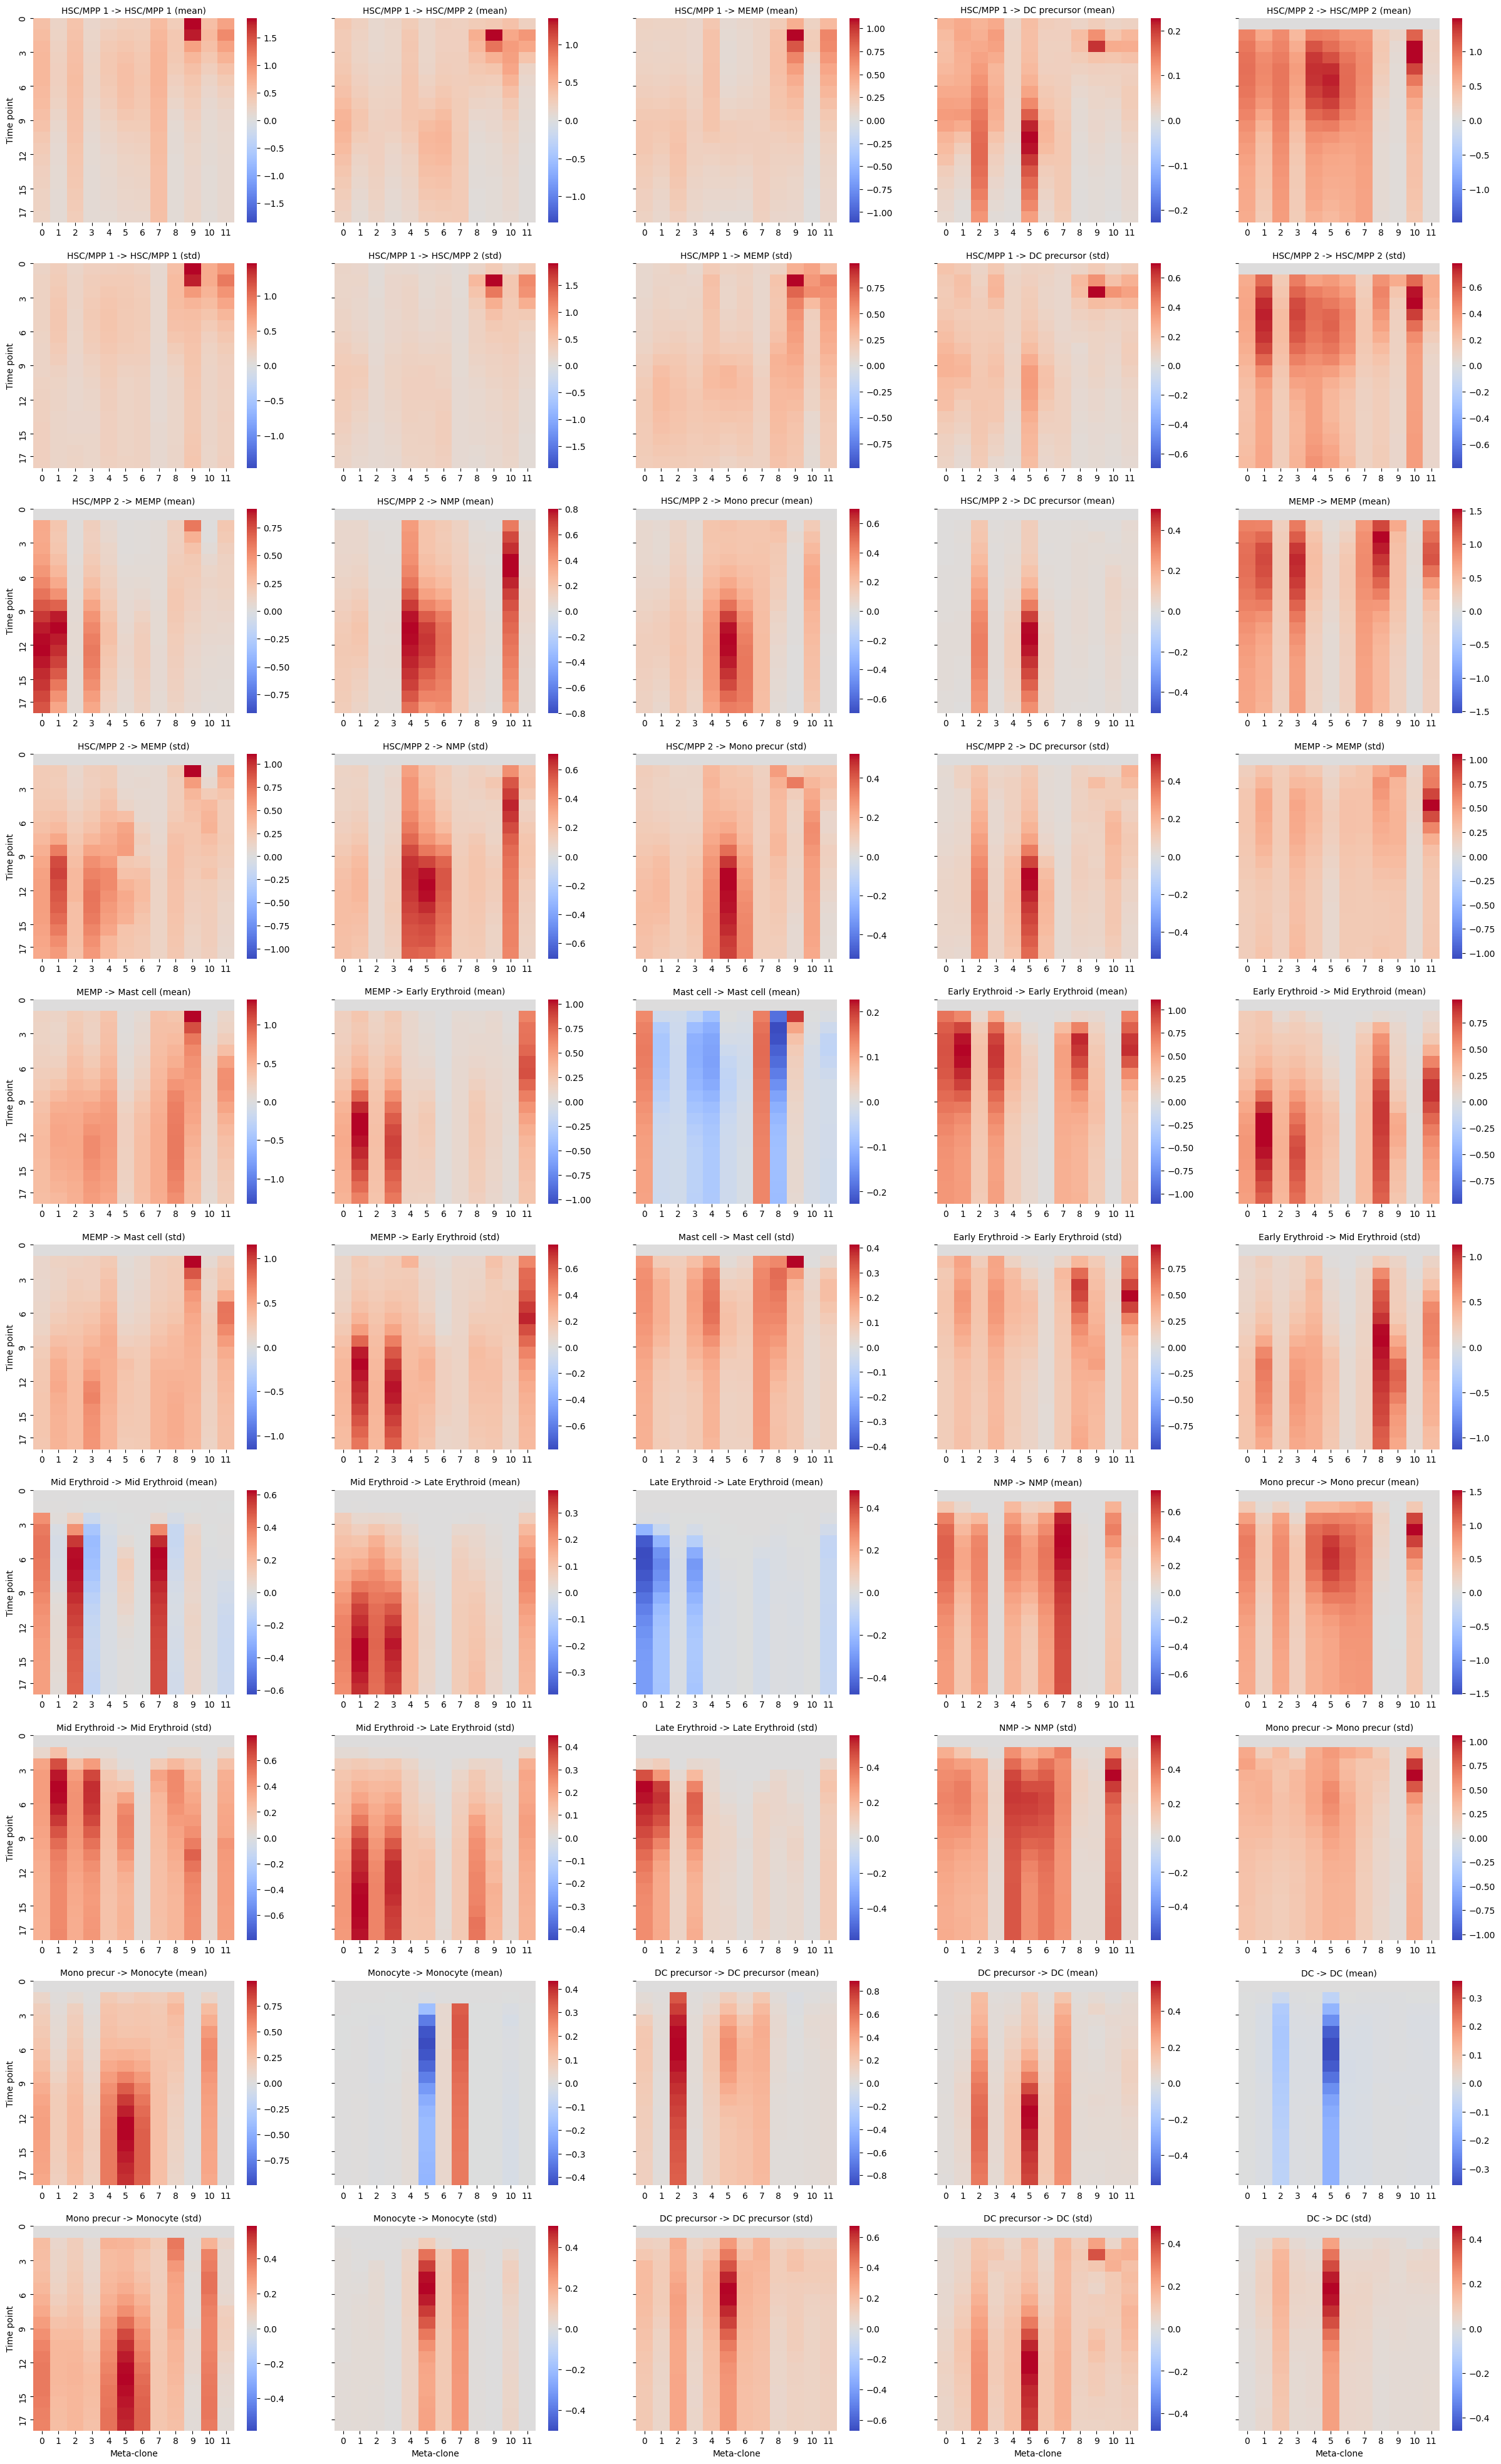

In [119]:
# Assuming data is a 4D numpy array with dimensions (bootstraps, time points, meta-clones, rates)
mean_data = np.mean(data_selected[:, :, :-1, :], axis=1)  # Calculate mean along the bootstraps dimension
std_data = np.std(data_selected[:, :, :-1, :], axis=1)  # Calculate standard deviation along the bootstraps dimension

fig, axs = plt.subplots(10, 5, figsize=(30, 50), sharex=False, sharey=True) 

for rate in range(mean_data.shape[2]):
    row = 2 * (rate // 5)  # Calculate the row index for the mean and std plots
    col = rate % 5  # Calculate the column index for the mean and std plots

    mean_data_rate = mean_data[:, :, rate]
    std_data_rate = std_data[:, :, rate]

    max_val_mean = max(mean_data_rate.max(), abs(mean_data_rate.min()))
    max_val_std = max(std_data_rate.max(),  abs(std_data_rate.min()))

    # Plot the mean heatmap
    sns.heatmap(mean_data_rate, cmap='coolwarm', ax=axs[row, col], vmin=-max_val_mean, vmax=max_val_mean)
    axs[row, col].set_title(f"{cols[rate]} (mean)", fontsize=10)
    axs[row, 0].set_ylabel("Time point", fontsize=10)

    # Plot the std heatmap
    sns.heatmap(std_data_rate, cmap='coolwarm', ax=axs[row + 1, col], vmin=-max_val_std, vmax=max_val_std)
    axs[row + 1, col].set_title(f"{cols[rate]} (std)", fontsize=10)
    axs[9, col].set_xlabel("Meta-clone", fontsize=10)
    axs[row + 1, 0].set_ylabel("Time point", fontsize=10)
    axs[row + 1, 0].set_yticks([0, 3, 6, 9, 12, 15, 17], [0, 3, 6, 9, 12, 15, 17])

# plt.suptitle('Summary of bootstrapping results (Cord blood)', fontsize=12, y=0.92)
plt.savefig(f'./Reviewer1_Q10_1.png', dpi=600, bbox_inches='tight', transparent=True)

### Bootstrapping results for all transition pairs (Mouse hematopoiesis)

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../results/WeinrebDynamicRates/model_last.pt'
ref_model = torch.load(path, map_location='cuda:1')
ref_model.config['system']['gpu_id'] = 'cuda:1'
ref_model.model.block.clipping = False

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
model_list = []

for name in tqdm(os.listdir("./trials/original/checkpoints/WeinrebDynamicBoots/0301_170419/models")):
    boots = torch.load(f'./trials/original/checkpoints/WeinrebDynamicBoots/0301_170419/models/{name}', map_location='cuda:1')
    boots.model.block.clipping = False
    
    model_list.append(boots)
    model_list[-1].config['system']['gpu_id'] = 'cuda:1'

100%|██████████| 700/700 [00:21<00:00, 32.24it/s]


In [4]:
from clonaltrans.utils import get_post_masks

total_K_time = [] 
ref_K_time = [] 
x = torch.linspace(0, int(ref_model.t_observed[-1].item()), int(ref_model.t_observed[-1].item() + 1)).to('cpu')

for tpoint in tqdm(x):
    total_K = [] 

    for model in model_list:
        masks = get_post_masks(model, tpoint)

        K = model.get_matrix_K(K_type='dynamic', eval=True, tpoint=tpoint).detach().cpu().numpy()
        K[masks[0], masks[1], :] = 0
        total_K.append(K)

    masks = get_post_masks(ref_model, tpoint)
    ref_K = ref_model.get_matrix_K(K_type='dynamic', eval=True, tpoint=tpoint).detach().cpu().numpy()
    ref_K[masks[0], masks[1], :] = 0

    total_K = np.stack(total_K) # (b, c, p, p)

    total_K_time.append(total_K)
    ref_K_time.append(ref_K) # (t, b, c, p, p) (t, c, p, p)

  0%|          | 0/7 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 7/7 [26:40<00:00, 228.57s/it]


In [5]:
total_K_time = np.stack(total_K_time)
ref_K_time = np.stack(ref_K_time)

paga_graph = pd.read_csv('./datasets/Weinreb/data/graph_table.csv', index_col=0).astype(np.int32)
annotations = pd.read_csv('./datasets/Weinreb/data/annotations.csv')

In [6]:
np.savez('rates_boots_reference.npz', data1=total_K_time, data2=ref_K_time)

In [7]:
total_K_time_flatten = total_K_time.reshape(*total_K_time.shape[:-2], -1)

paga = paga_graph.values
np.fill_diagonal(paga, 1)
paga_flatten = paga.flatten()

In [8]:
mask_indices = np.where(paga_flatten == 1)
data_selected = total_K_time_flatten[..., mask_indices].squeeze()
print(data_selected.shape) 

(7, 700, 14, 44)


In [9]:
from itertools import product

cols = []
for pop1, pop2 in product(range(paga_graph.shape[0]), range(paga_graph.shape[1])):
    if paga_graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(annotations['populations'].values[pop1], annotations['populations'].values[pop2]))

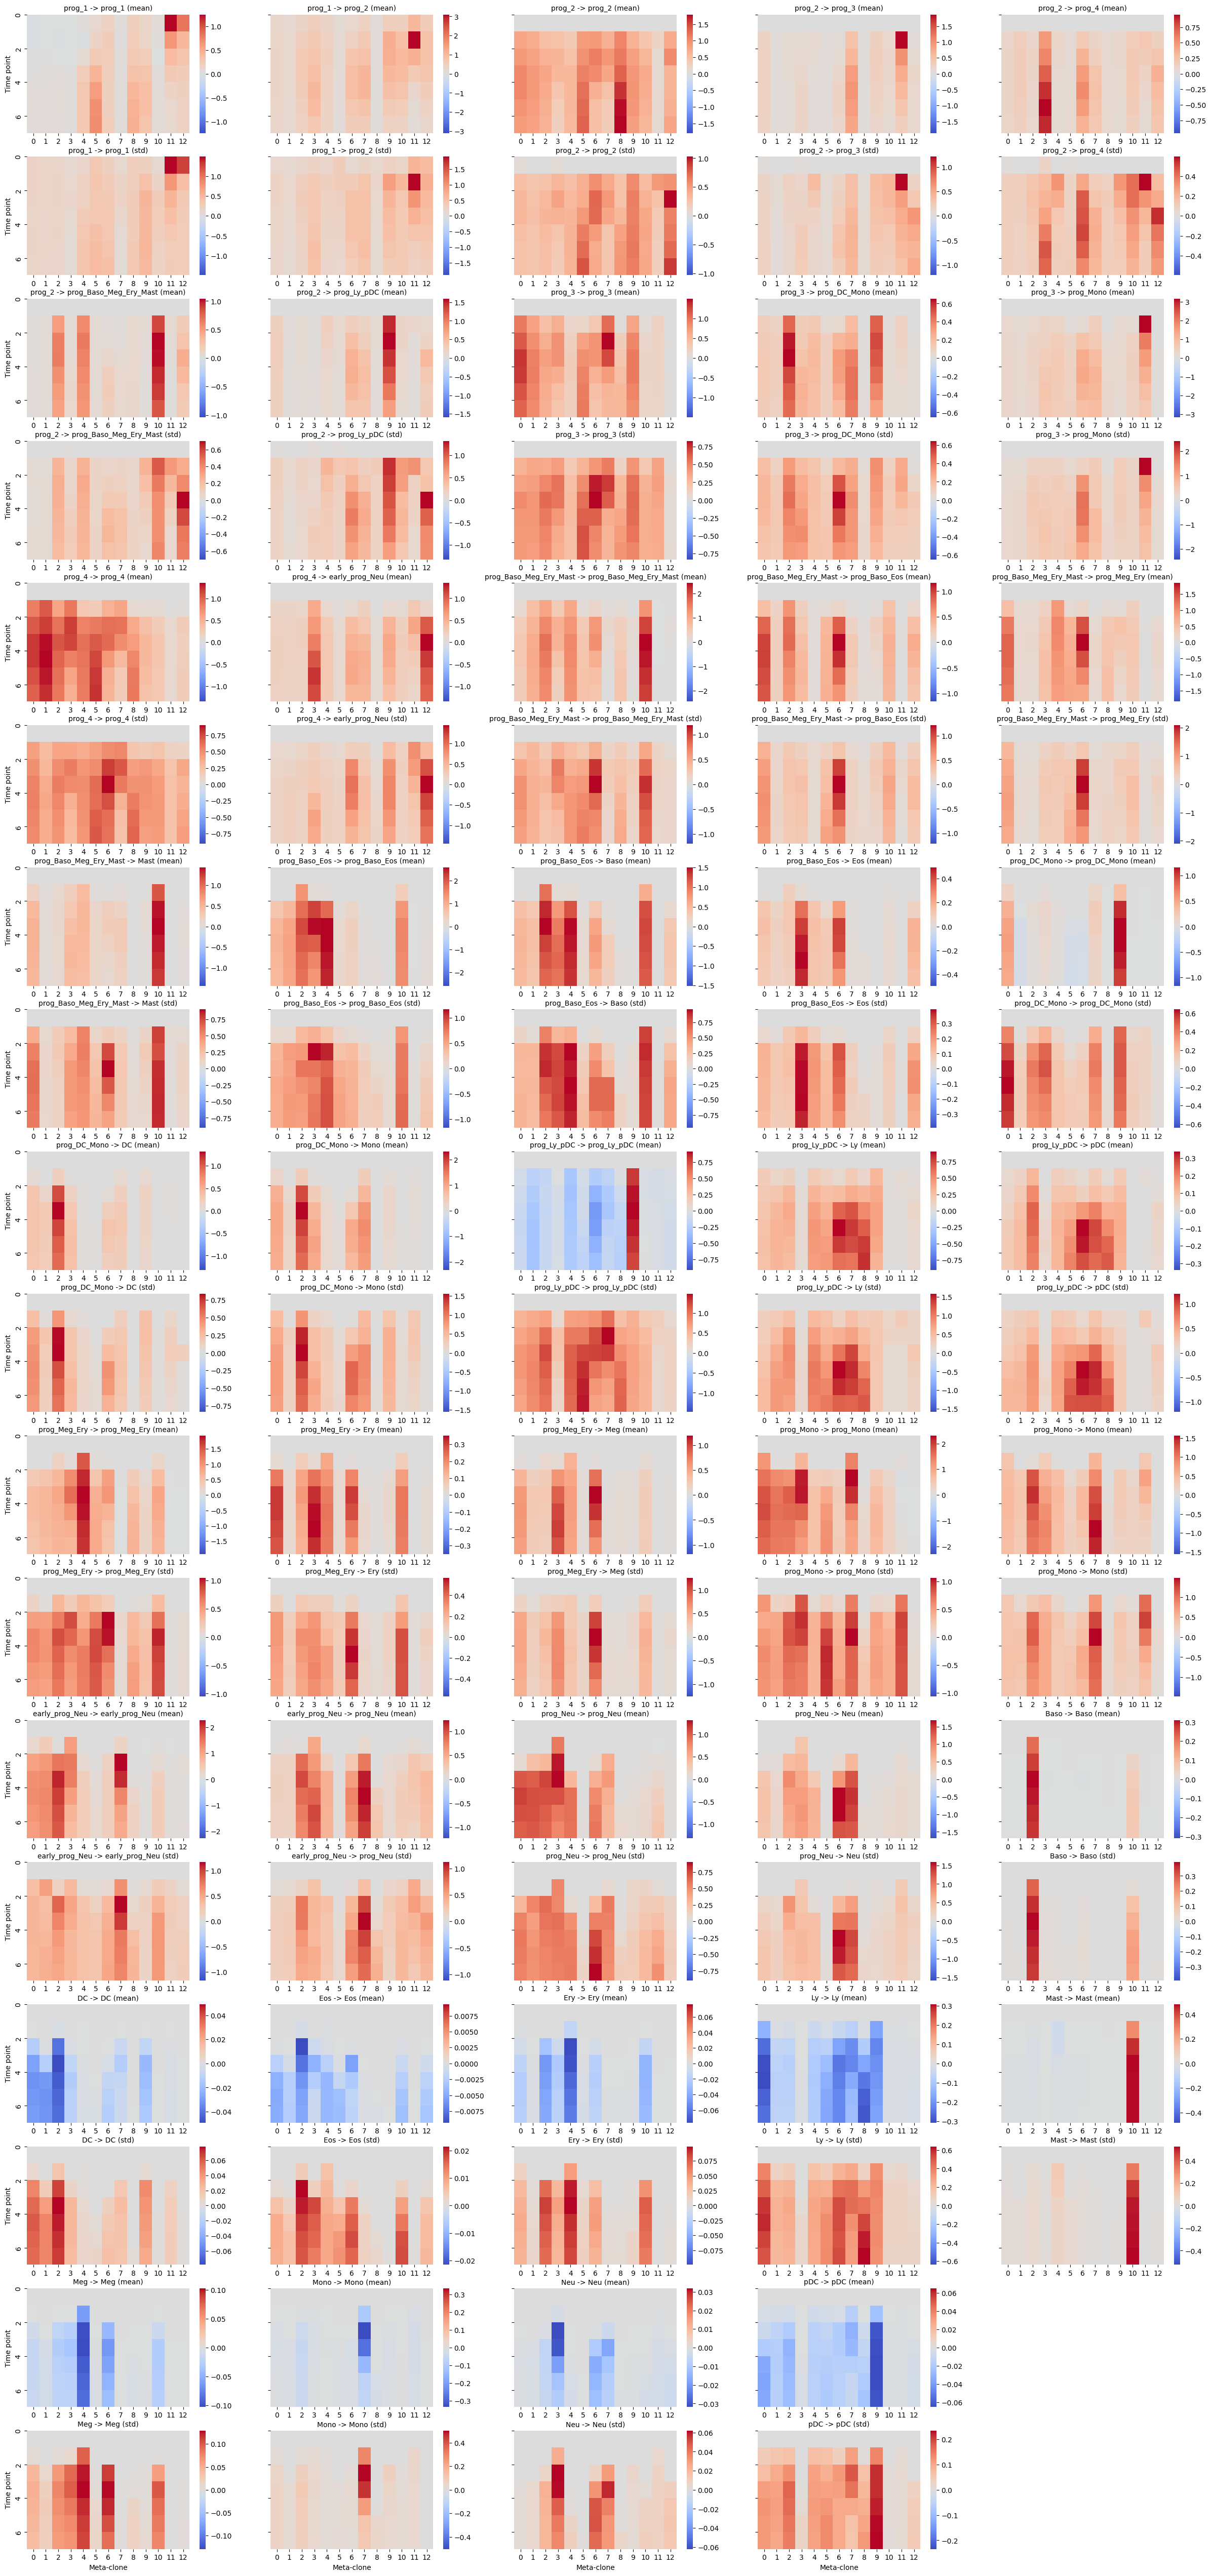

In [13]:
# Assuming data is a 4D numpy array with dimensions (bootstraps, time points, meta-clones, rates)
mean_data = np.mean(data_selected[:, :, :-1, :], axis=1)  # Calculate mean along the bootstraps dimension
std_data = np.std(data_selected[:, :, :-1, :], axis=1)  # Calculate standard deviation along the bootstraps dimension

fig, axs = plt.subplots(18, 5, figsize=(30, 65), sharex=False, sharey=True) 

for rate in range(mean_data.shape[2]):
    row = 2 * (rate // 5)  # Calculate the row index for the mean and std plots
    col = rate % 5  # Calculate the column index for the mean and std plots

    mean_data_rate = mean_data[:, :, rate]
    std_data_rate = std_data[:, :, rate]

    max_val_mean = max(mean_data_rate.max(), abs(mean_data_rate.min()))
    max_val_std = max(std_data_rate.max(),  abs(std_data_rate.min()))

    # Plot the mean heatmap
    sns.heatmap(mean_data_rate, cmap='coolwarm', ax=axs[row, col], vmin=-max_val_mean, vmax=max_val_mean)
    axs[row, col].set_title(f"{cols[rate]} (mean)", fontsize=10)
    axs[row, 0].set_ylabel("Time point", fontsize=10)

    # Plot the std heatmap
    sns.heatmap(std_data_rate, cmap='coolwarm', ax=axs[row + 1, col], vmin=-max_val_std, vmax=max_val_std)
    axs[row + 1, col].set_title(f"{cols[rate]} (std)", fontsize=10)
    axs[17, col].set_xlabel("Meta-clone", fontsize=10)
    axs[row + 1, 0].set_ylabel("Time point", fontsize=10)
    axs[row + 1, 0].set_yticks([0, 2, 4, 6], [0, 2, 4, 6])

axs[16, 4].axis('off')
axs[17, 4].axis('off')

# plt.suptitle('Summary of bootstrapping results (Cord blood)', fontsize=12, y=0.92)
plt.savefig(f'./Reviewer1_Q10_2.png', dpi=600, bbox_inches='tight', transparent=True)

### Gaps within histogram of mean # of divisions needed (Cord blood)

In [6]:
import os
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [7]:
paga_graph = pd.read_csv('./datasets/CordBlood_Refine/data/graph_table.csv', index_col=0).astype(np.int32)
annotations = pd.read_csv('./datasets/CordBlood_Refine/data/annotations.csv')

cluster_names = annotations['populations'].dropna().tolist()

In [22]:
from clonaltrans.pl import get_num_div
gillespie_dir = './trials/original/checkpoints/CordBloodDynamicGillespie/0605_131252/models/'

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        get_num_div(cluster_names, gillespie_dir=gillespie_dir_clones)

Total # of gillespie trials for ['models', 'clone_0']: 980
Total # of gillespie trials for ['models', 'clone_1']: 951
Total # of gillespie trials for ['models', 'clone_2']: 970
Total # of gillespie trials for ['models', 'clone_3']: 982
Total # of gillespie trials for ['models', 'clone_4']: 958
Total # of gillespie trials for ['models', 'clone_5']: 946
Total # of gillespie trials for ['models', 'clone_6']: 957
Total # of gillespie trials for ['models', 'clone_7']: 957
Total # of gillespie trials for ['models', 'clone_8']: 954
Total # of gillespie trials for ['models', 'clone_9']: 966
Total # of gillespie trials for ['models', 'clone_10']: 930
Total # of gillespie trials for ['models', 'clone_11']: 927
Total # of gillespie trials for ['models', 'clone_12']: 999


In [ ]:
from clonaltrans.pl import visualize_num_div
gillespie_dir_valid = os.path.join(gillespie_dir, 'clone_12')

visualize_num_div(cluster_names, gillespie_dir=gillespie_dir_valid, clone_name='background', save=True)

### Gaps within histogram of mean # of divisions needed (Mouse hematopoiesis)

In [2]:
import os
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
paga_graph = pd.read_csv('./datasets/Weinreb/data/graph_table.csv', index_col=0).astype(np.int32)
annotations = pd.read_csv('./datasets/Weinreb/data/annotations.csv')

cluster_names = annotations['populations'].dropna().tolist()

In [11]:
from clonaltrans.pl import get_num_div
gillespie_dir = './trials/original/checkpoints/WeinrebDynamicGillespie/0301_211649/models/'

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        get_num_div(cluster_names, gillespie_dir=gillespie_dir_clones)

Total # of gillespie trials for ['models', 'clone_0']: 995
Total # of gillespie trials for ['models', 'clone_1']: 993
Total # of gillespie trials for ['models', 'clone_2']: 992
Total # of gillespie trials for ['models', 'clone_3']: 998
Total # of gillespie trials for ['models', 'clone_4']: 995
Total # of gillespie trials for ['models', 'clone_5']: 990
Total # of gillespie trials for ['models', 'clone_6']: 995
Total # of gillespie trials for ['models', 'clone_7']: 994
Total # of gillespie trials for ['models', 'clone_8']: 988
Total # of gillespie trials for ['models', 'clone_9']: 988
Total # of gillespie trials for ['models', 'clone_10']: 979
Total # of gillespie trials for ['models', 'clone_11']: 930
Total # of gillespie trials for ['models', 'clone_12']: 921
Total # of gillespie trials for ['models', 'clone_13']: 996


In [23]:
from clonaltrans.pl import visualize_num_div
gillespie_dir_valid = os.path.join(gillespie_dir, 'clone_3')

visualize_num_div(cluster_names, gillespie_dir=gillespie_dir_valid, clone_name='meta-clone 3', save=True)

### Performance if number of meta-clones varies (Cord blood)

In [11]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans')

In [12]:
model_list = []

for name in tqdm(natsorted(os.listdir("../trials/revision_1_nni/checkpoints/CBLeidenResolution"))):
    if os.path.exists(f'../trials/revision_1_nni/checkpoints/CBLeidenResolution/{name}/model_last.pt'):
        gpu_id = 1
        temp = torch.load(f'../trials/revision_1_nni/checkpoints/CBLeidenResolution/{name}/model_last.pt', map_location=f'cuda:{gpu_id}')
        temp.model.block.clipping = False
        
        model_list.append(temp)
        model_list[-1].config['system']['gpu_id'] = gpu_id

100%|██████████| 51/51 [00:00<00:00, 166.90it/s]


In [13]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans')

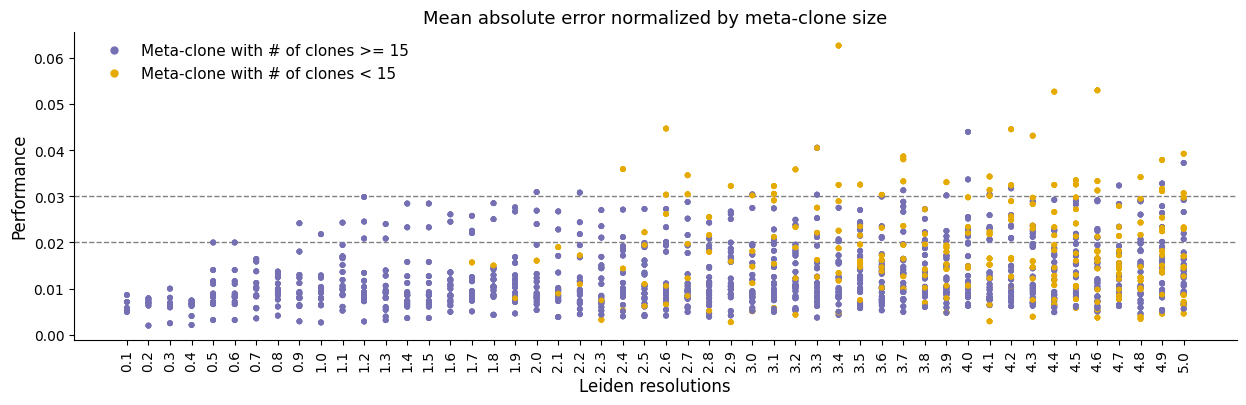

In [14]:
from torch import nn
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

L1loss = nn.L1Loss(reduction='mean')
num_trials = len(model_list)
num_time_points = model_list[0].N.shape[0]

cmap = plt.get_cmap('Dark2')
cmap_colors = cmap(np.linspace(0, 1, num_time_points))

colors = []
performance_data = []
for model in model_list:
    observations = model.N
    predictions = model.eval_model(model.t_observed)

    colors_clone = []
    performance_clone = []
    for clone in range(model.N.shape[1]):

        loss, sum = 0, 0
        for time in range(model.N.shape[0]):
            x = (observations[time, clone, :]).detach().cpu().numpy()
            y = (predictions[time, clone, :]).detach().cpu().numpy()

            # loss = L1loss(x, y).numpy() / np.mean(x.numpy())
            # loss = (1 - loss.item()) * 100
            
            loss += mean_absolute_error(x / model.config['user_trainer']['scaling_factor'][time], y / model.config['user_trainer']['scaling_factor'][time])
            sum += x / model.config['user_trainer']['scaling_factor'][time]

        init_csv = pd.read_csv(os.path.join('./trials/revision_1_nni/datasplit/CBLeidenResolution', os.path.split(model.config.log_dir)[1], 'nni_data/initial_condition.csv'), index_col=0)
        colors_clone.append(cmap_colors[1] if init_csv['leiden'].values[clone] >= 15 else cmap_colors[2])
        performance_clone.append(loss / np.sum(sum))
    
    colors.append(colors_clone)
    performance_data.append(performance_clone)

plt.figure(figsize=(15, 4))

for trial in range(num_trials):
    for time in range(num_time_points):
        x_values = [trial + 1] * len(performance_data[trial])  # x-values for the current trial
        y_values = performance_data[trial]  # y-values for the current trial
        plt.scatter(x_values, y_values, s=10, c=colors[trial], zorder=2)

plt.xlabel('Leiden resolutions', fontsize=12)
plt.ylabel('Performance', fontsize=12)
plt.title('Mean absolute error normalized by meta-clone size', fontsize=13)
plt.xticks(ticks=range(1, num_trials + 1), labels=[f'{i * 0.1:.1f}' for i in range(1, num_trials + 1)], rotation=90)

legend_elements = [Line2D([0], [0], marker='o', color=cmap_colors[1], markersize=5, linestyle=''), Line2D([0], [0], marker='o', color=cmap_colors[2], markersize=5, linestyle='')]
labels = ['Meta-clone with # of clones >= 15', 'Meta-clone with # of clones < 15']
plt.legend(legend_elements, labels, loc='right', fontsize=11, bbox_to_anchor=(0.3, 0.9), frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.02, color='grey', linewidth=1, zorder=1, linestyle='dashed')
ax.axhline(0.03, color='grey', linewidth=1, zorder=1, linestyle='dashed')

plt.savefig(f'./Reviewer2_Q2_1.svg', dpi=600, bbox_inches='tight', transparent=True)

### Performance if number of meta-clones varies (Mouse hematopoiesis)

In [15]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans')

In [16]:
model_list = []

for name in tqdm(natsorted(os.listdir("../trials/revision_1_nni/checkpoints/WRLeidenResolution"))):
    if os.path.exists(f'../trials/revision_1_nni/checkpoints/WRLeidenResolution/{name}/model_last.pt'):
        gpu_id = 1
        temp = torch.load(f'../trials/revision_1_nni/checkpoints/WRLeidenResolution/{name}/model_last.pt', map_location=f'cuda:{gpu_id}')
        temp.model.block.clipping = False
        
        model_list.append(temp)
        model_list[-1].config['system']['gpu_id'] = gpu_id

100%|██████████| 51/51 [00:00<00:00, 77.85it/s] 


In [17]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans')

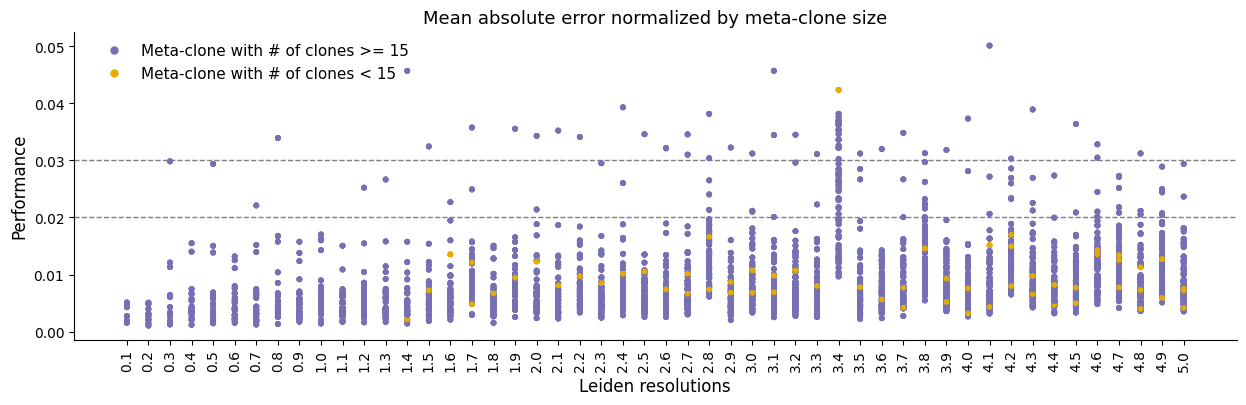

In [18]:
from torch import nn
from matplotlib.lines import Line2D
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error

L1loss = nn.L1Loss(reduction='mean')
num_trials = len(model_list)
num_time_points = model_list[0].N.shape[0]

cmap = plt.get_cmap('Dark2')
cmap_colors = cmap(np.linspace(0, 1, num_time_points))

colors = []
performance_data = []
for model in model_list:
    observations = model.N
    predictions = model.eval_model(model.t_observed)

    colors_clone = []
    performance_clone = []
    for clone in range(model.N.shape[1]):

        loss, sum = 0, 0
        for time in range(model.N.shape[0]):
            x = (observations[time, clone, :]).detach().cpu().numpy()
            y = (predictions[time, clone, :]).detach().cpu().numpy()

            # loss = L1loss(x, y).numpy() / np.mean(x.numpy())
            # loss = (1 - loss.item()) * 100
            
            loss += mean_absolute_error(x / model.config['user_trainer']['scaling_factor'][time], y / model.config['user_trainer']['scaling_factor'][time])
            sum += x / model.config['user_trainer']['scaling_factor'][time]

        init_csv = pd.read_csv(os.path.join('./trials/revision_1_nni/datasplit/WRLeidenResolution', os.path.split(model.config.log_dir)[1], 'nni_data/initial_condition.csv'), index_col=0)
        colors_clone.append(cmap_colors[1] if init_csv['leiden'].values[clone] >= 15 else cmap_colors[2])
        performance_clone.append(loss / np.sum(sum))
    
    colors.append(colors_clone)
    performance_data.append(performance_clone)

plt.figure(figsize=(15, 4))

for trial in range(num_trials):
    for time in range(num_time_points):
        x_values = [trial + 1] * len(performance_data[trial])  # x-values for the current trial
        y_values = performance_data[trial]  # y-values for the current trial
        plt.scatter(x_values, y_values, s=10, c=colors[trial], zorder=2)

plt.xlabel('Leiden resolutions', fontsize=12)
plt.ylabel('Performance', fontsize=12)
plt.title('Mean absolute error normalized by meta-clone size', fontsize=13)
plt.xticks(ticks=range(1, num_trials + 1), labels=[f'{i * 0.1:.1f}' for i in range(1, num_trials + 1)], rotation=90)

legend_elements = [Line2D([0], [0], marker='o', color=cmap_colors[1], markersize=5, linestyle=''), Line2D([0], [0], marker='o', color=cmap_colors[2], markersize=5, linestyle='')]
labels = ['Meta-clone with # of clones >= 15', 'Meta-clone with # of clones < 15']
plt.legend(legend_elements, labels, loc='right', fontsize=11, bbox_to_anchor=(0.3, 0.9), frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0.02, color='grey', linewidth=1, zorder=1, linestyle='dashed')
ax.axhline(0.03, color='grey', linewidth=1, zorder=1, linestyle='dashed')

plt.savefig(f'./Reviewer2_Q2_2.svg', dpi=600, bbox_inches='tight', transparent=True)

### Individual UMAP for meta-clones (Mouse hematopoiesis)

In [2]:
adata = sc.read_h5ad('../../datasets/Weinreb/klein_update.h5ad')
adata

AnnData object with n_obs × n_vars = 126861 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'Meta clones', 'group'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
group_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
adata.obs['group'] = pd.Categorical(adata.obs['Meta clones'], categories=group_labels)

In [4]:
adata.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,Meta clones,group
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573,8,8
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440,8,8
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394,0,0
3,6.0,LK,Neutrophil,2,6.0,12,Neutrophil_12,early_prog_Neu,Clone_nan,-1.0,NaN
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972,4,4
...,...,...,...,...,...,...,...,...,...,...,...
130882,6.0,LSK,undiff,1,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_nan,-1.0,NaN
130883,6.0,LSK,undiff,1,6.0,0,undiff_0,prog_2,Clone_1374,5,5
130884,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan,-1.0,NaN
130885,6.0,LSK,Monocyte,1,6.0,2,Monocyte_2,Mono,Clone_nan,-1.0,NaN


In [ ]:
for label in group_labels:
    sc.set_figure_params(dpi_save=600, format='svg', figsize=(7, 6), transparent=True)
    sc.pl.umap(
        adata, color=['group'], size=40, legend_loc='right margin', 
        palette=sns.color_palette('tab20'), groups=label,
        frameon=False, title='', legend_fontsize=15, save=f'Reviewer3_Q8_{label}'
    )

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


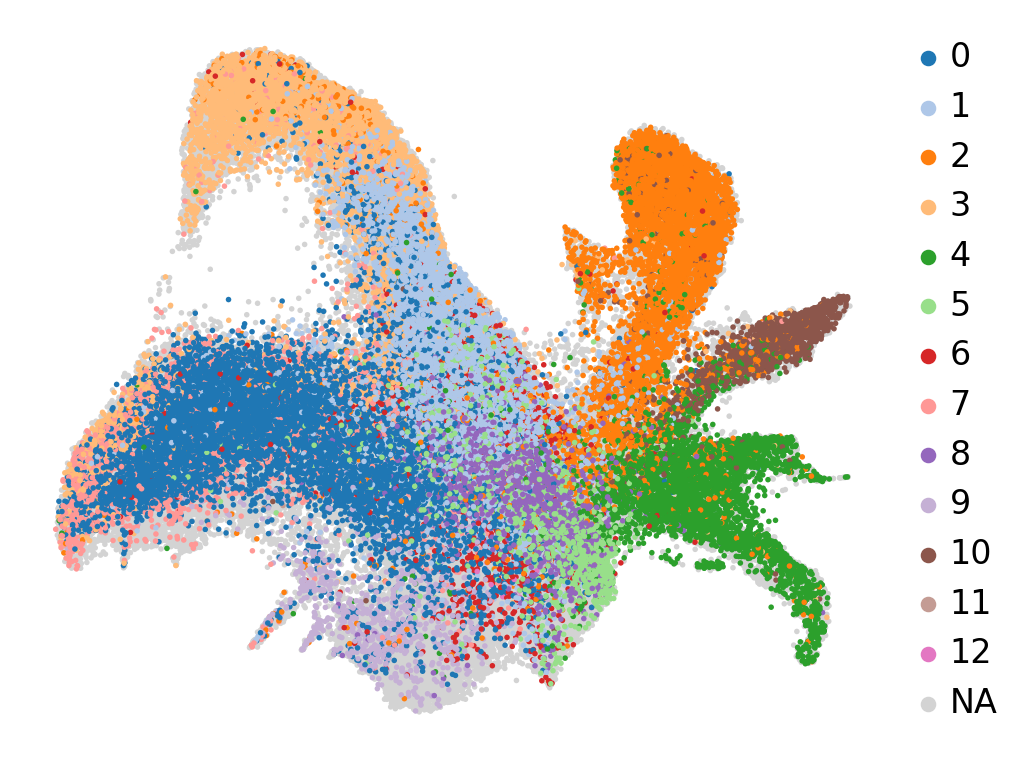

In [8]:
sc.set_figure_params(dpi_save=600, format='svg', figsize=(7, 6), transparent=True)
sc.pl.umap(
    adata, color=['group'], size=25, legend_loc='right margin', 
    palette=sns.color_palette('tab20'),
    frameon=False, title='', legend_fontsize=15, save='metaclones'
)

### Performance of const mode given time-invariant simulated rates (Cord blood)

In [53]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/CordBloodConstRates/0929_115228/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/CordBloodDynamicRates/0929_115437/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [54]:
from clonaltrans.pl import get_error_rate
mae, mean = get_error_rate('./trials/revision_1/checkpoints/SimulationsConst/const', model_const)

mae = np.swapaxes(np.array(mae), 0, 1) # (num_trials, num_time_points, rates) -> (num_time_points, num_trials, rates)
mean = np.swapaxes(np.array(mean), 0, 1)

mae = mae.reshape(mae.shape[0], -1)
mean = np.mean(mean, axis=1)

mae = [list(mae[i]) for i in range(len(mae))]
text = f'$Mean_{2} = {mean[0]:.3f}$\n$Mean_{3} = {mean[1]:.3f}$\n$Mean_{4} = {mean[2]:.3f}$\n$Mean_{5} = {mean[3]:.3f}$'

  0%|          | 0/18 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:05<00:00,  3.03it/s]


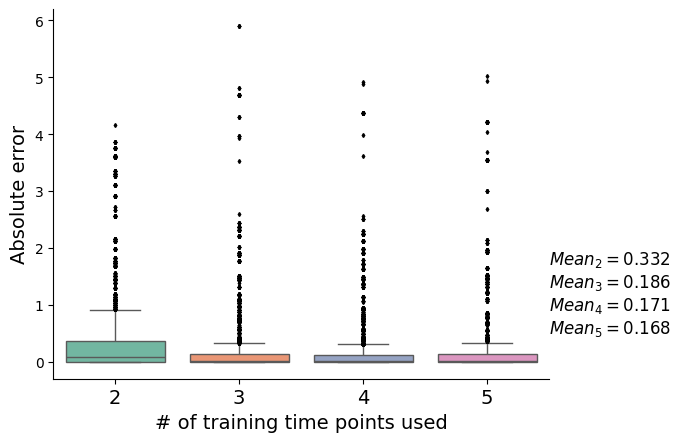

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(mae, palette='Set2',
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], [2, 3, 4, 5], fontsize=14)
plt.ylabel('Absolute error', fontsize=14)
plt.text(3.5, 0.5, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_1.svg', dpi=300, bbox_inches='tight', transparent=True)

In [56]:
from clonaltrans.data import simulation_const

K = model_const.get_matrix_K(eval=True)

N = simulation_const(
    K,
    model_const.L.detach().cpu(),
    model_const.config,
    torch.tensor([0.0, 2.0, 5.0, 8.0, 12.0, 15.0]).to(device),
    model_const.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [57]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsConst/const', 
    N, 
    valid_times=[0.0, 2.0, 5.0, 8.0, 12.0, 15.0]
)

In [58]:
text = f'$Mean_{2} = {np.mean(corr[0]):.3f}$\n$Mean_{3} = {np.mean(corr[1]):.3f}$\n$Mean_{4} = {np.mean(corr[2]):.3f}$\n$Mean_{5} = {np.mean(corr[3]):.3f}$'

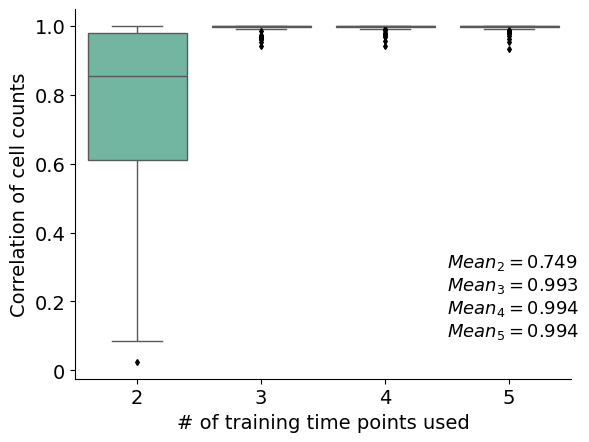

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(corr, palette='Set2', 
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 
        'black', 
        'markeredgecolor': 'black',
        'markersize': 3
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], ['2', '3', '4', '5'], fontsize=14)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)
plt.ylabel('Correlation of cell counts', fontsize=14)
plt.text(2.5, 0.1, text, fontsize=13)
plt.savefig('./Reviewer2_Q1_2.svg', dpi=300, bbox_inches='tight', transparent=True)

In [41]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

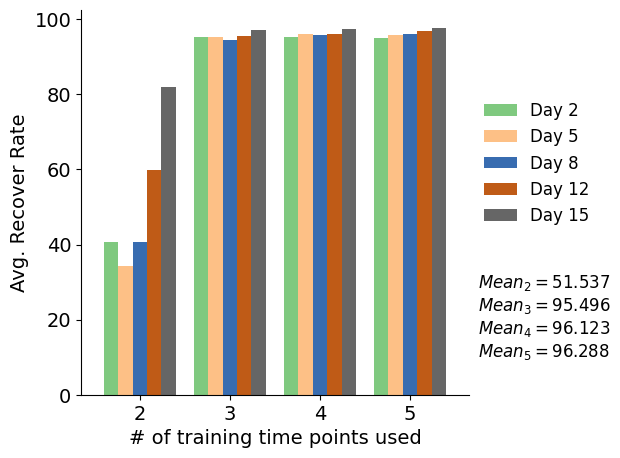

In [50]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 2', 'Day 5', 'Day 8', 'Day 12', 'Day 15']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_3.svg', dpi=300, bbox_inches='tight', transparent=True)

### Performance of dynamic mode given time-invariant simulated rates (Cord blood)

In [60]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/CordBloodConstRates/0929_115228/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/CordBloodDynamicRates/0929_115437/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [62]:
from clonaltrans.pl import get_error_rate
mae, mean = get_error_rate('./trials/revision_1/checkpoints/SimulationsConst/dynamic', model_const)

mae = np.swapaxes(np.array(mae), 0, 1) # (num_trials, num_time_points, rates) -> (num_time_points, num_trials, rates)
mean = np.swapaxes(np.array(mean), 0, 1)

mae = mae.reshape(mae.shape[0], -1)
mean = np.mean(mean, axis=1)

mae = [list(mae[i]) for i in range(len(mae))]
text = f'$Mean_{2} = {mean[0]:.3f}$\n$Mean_{3} = {mean[1]:.3f}$\n$Mean_{4} = {mean[2]:.3f}$\n$Mean_{5} = {mean[3]:.3f}$'

100%|██████████| 18/18 [01:08<00:00,  3.78s/it]


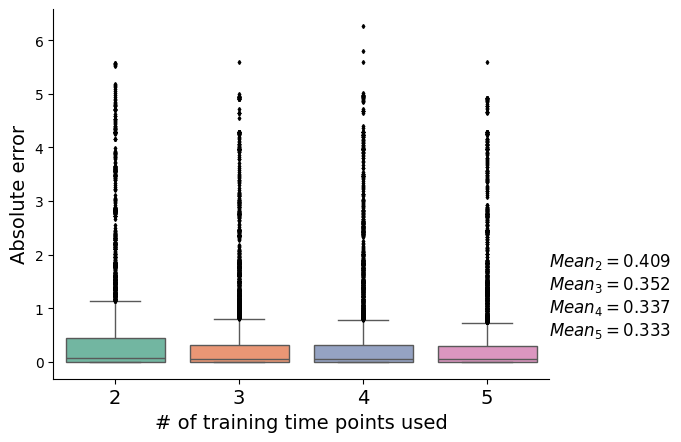

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(mae, palette='Set2',
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], [2, 3, 4, 5], fontsize=14)
plt.ylabel('Absolute error', fontsize=14)
plt.text(3.5, 0.5, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_4.svg', dpi=300, bbox_inches='tight', transparent=True)

In [65]:
from clonaltrans.data import simulation_const

K = model_const.get_matrix_K(eval=True)

N = simulation_const(
    K,
    model_const.L.detach().cpu(),
    model_const.config,
    torch.tensor([0.0, 2.0, 5.0, 8.0, 12.0, 15.0]).to(device),
    model_const.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [66]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsConst/dynamic', 
    N, 
    valid_times=[0.0, 2.0, 5.0, 8.0, 12.0, 15.0]
)

In [68]:
text = f'$Mean_{2} = {np.mean(corr[0]):.3f}$\n$Mean_{3} = {np.mean(corr[1]):.3f}$\n$Mean_{4} = {np.mean(corr[2]):.3f}$\n$Mean_{5} = {np.mean(corr[3]):.3f}$'

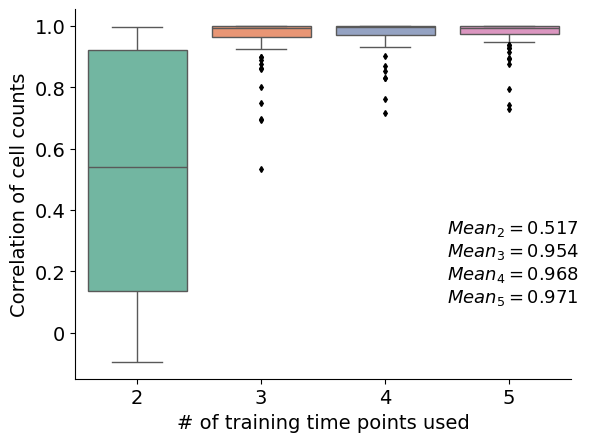

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(corr, palette='Set2', 
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 
        'black', 
        'markeredgecolor': 'black',
        'markersize': 3
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], ['2', '3', '4', '5'], fontsize=14)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)
plt.ylabel('Correlation of cell counts', fontsize=14)
plt.text(2.5, 0.1, text, fontsize=13)
plt.savefig('./Reviewer2_Q1_5.svg', dpi=300, bbox_inches='tight', transparent=True)

In [71]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

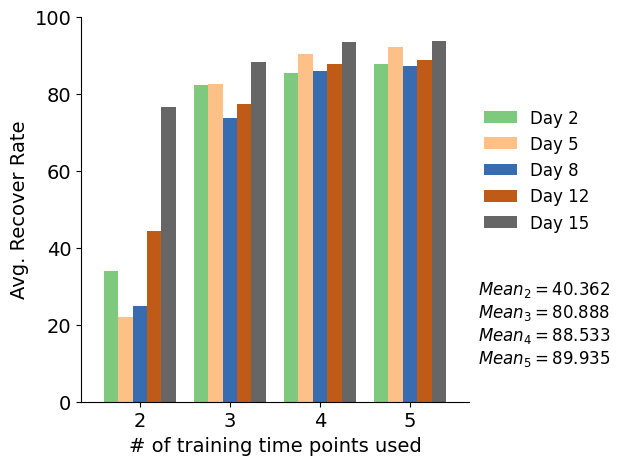

In [73]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 2', 'Day 5', 'Day 8', 'Day 12', 'Day 15']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_6.svg', dpi=300, bbox_inches='tight', transparent=True)

### Performance of const mode given time-variant simulated rates (Mouse hematopoiesis)

In [2]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebConstRates/0929_115327/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
from clonaltrans.pl import get_error_rate
mae, mean = get_error_rate('./trials/revision_1/checkpoints/SimulationsDynamic/const', model_dyna)

mae = np.swapaxes(np.array(mae), 0, 1) # (num_trials, num_time_points, rates) -> (num_time_points, num_trials, rates)
mean = np.swapaxes(np.array(mean), 0, 1)

mae = mae.reshape(mae.shape[0], -1)
mean = np.mean(mean, axis=1)

mae = [list(mae[i]) for i in range(len(mae))]
text = f'$Mean_{2} = {mean[0]:.3f}$\n$Mean_{3} = {mean[1]:.3f}$\n$Mean_{4} = {mean[2]:.3f}$\n$Mean_{5} = {mean[3]:.3f}$'

  0%|          | 0/7 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 7/7 [00:08<00:00,  1.21s/it]


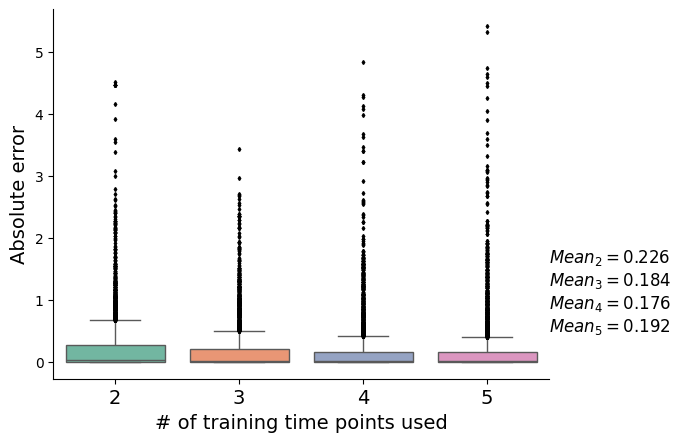

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(mae, palette='Set2',
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], [2, 3, 4, 5], fontsize=14)
plt.ylabel('Absolute error', fontsize=14)
plt.text(3.5, 0.5, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_7.svg', dpi=300, bbox_inches='tight', transparent=True)

In [5]:
from clonaltrans.data import simulation_dyna

K1_encode = model_dyna.model.block.K1_encode.detach()
K1_decode = model_dyna.model.block.K1_decode.detach()
K2_encode = model_dyna.model.block.K2_encode.detach()
K2_decode = model_dyna.model.block.K2_decode.detach()

N = simulation_dyna(
    K1_encode, K1_decode, K2_encode, K2_decode, 
    model_dyna.L.detach().cpu(), 
    model_dyna.config,
    torch.tensor([0.0, 1.0, 3.0, 5.0, 7.0]).to(device),
    model_dyna.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [6]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsDynamic/const', 
    N, 
    valid_times=[0.0, 1.0, 3.0, 5.0, 7.0]
)

In [7]:
text = f'$Mean_{2} = {np.mean(corr[0]):.3f}$\n$Mean_{3} = {np.mean(corr[1]):.3f}$\n$Mean_{4} = {np.mean(corr[2]):.3f}$\n$Mean_{5} = {np.mean(corr[3]):.3f}$'

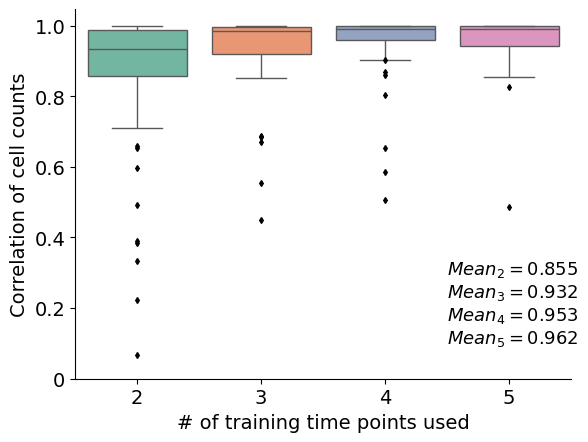

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(corr, palette='Set2', 
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 
        'black', 
        'markeredgecolor': 'black',
        'markersize': 3
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], ['2', '3', '4', '5'], fontsize=14)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)
plt.ylabel('Correlation of cell counts', fontsize=14)
plt.text(2.5, 0.1, text, fontsize=13)
plt.savefig('./Reviewer2_Q1_8.svg', dpi=300, bbox_inches='tight', transparent=True)

In [9]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

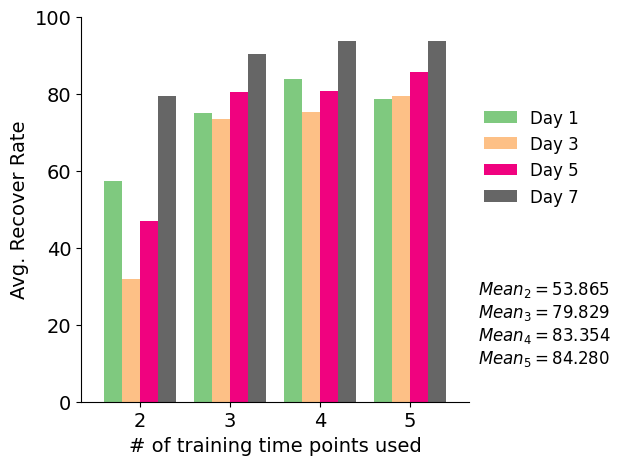

In [10]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 1', 'Day 3', 'Day 5', 'Day 7']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_9.svg', dpi=300, bbox_inches='tight', transparent=True)

### Performance of dynamic mode given time-variant simulated rates (Mouse hematopoiesis)

In [2]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebConstRates/0929_115327/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
from clonaltrans.pl import get_error_rate
mae, mean = get_error_rate('./trials/revision_1/checkpoints/SimulationsDynamic/dynamic', model_dyna)

mae = np.swapaxes(np.array(mae), 0, 1) # (num_trials, num_time_points, rates) -> (num_time_points, num_trials, rates)
mean = np.swapaxes(np.array(mean), 0, 1)

mae = mae.reshape(mae.shape[0], -1)
mean = np.mean(mean, axis=1)

mae = [list(mae[i]) for i in range(len(mae))]
text = f'$Mean_{2} = {mean[0]:.3f}$\n$Mean_{3} = {mean[1]:.3f}$\n$Mean_{4} = {mean[2]:.3f}$\n$Mean_{5} = {mean[3]:.3f}$'

  0%|          | 0/7 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 7/7 [00:11<00:00,  1.59s/it]


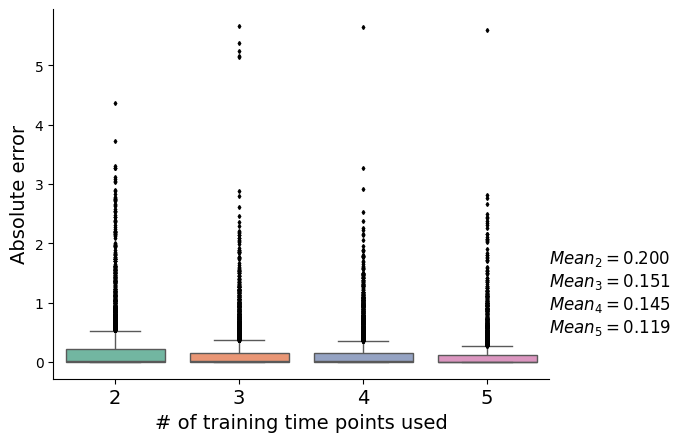

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(mae, palette='Set2',
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], [2, 3, 4, 5], fontsize=14)
plt.ylabel('Absolute error', fontsize=14)
plt.text(3.5, 0.5, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_10.svg', dpi=300, bbox_inches='tight', transparent=True)

In [4]:
from clonaltrans.data import simulation_dyna

K1_encode = model_dyna.model.block.K1_encode.detach()
K1_decode = model_dyna.model.block.K1_decode.detach()
K2_encode = model_dyna.model.block.K2_encode.detach()
K2_decode = model_dyna.model.block.K2_decode.detach()

N = simulation_dyna(
    K1_encode, K1_decode, K2_encode, K2_decode, 
    model_dyna.L.detach().cpu(), 
    model_dyna.config,
    torch.tensor([0.0, 1.0, 3.0, 5.0, 7.0]).to(device),
    model_dyna.N[0].detach().cpu()
)

In [5]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsDynamic/dynamic', 
    N, 
    valid_times=[0.0, 1.0, 3.0, 5.0, 7.0]
)

In [6]:
text = f'$Mean_{2} = {np.mean(corr[0]):.3f}$\n$Mean_{3} = {np.mean(corr[1]):.3f}$\n$Mean_{4} = {np.mean(corr[2]):.3f}$\n$Mean_{5} = {np.mean(corr[3]):.3f}$'

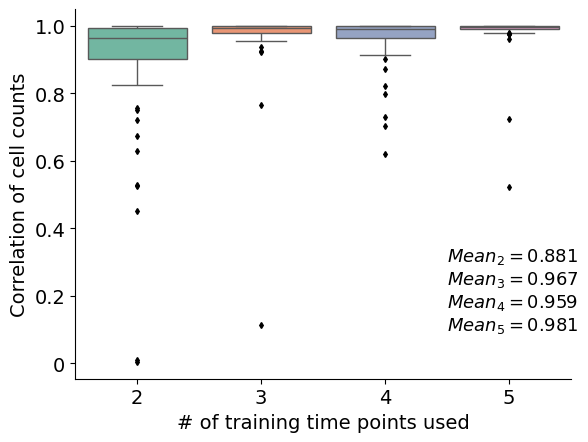

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
ax = sns.boxplot(corr, palette='Set2', 
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 
        'black', 
        'markeredgecolor': 'black',
        'markersize': 3
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('# of training time points used', fontsize=14)
plt.xticks([0, 1, 2, 3], ['2', '3', '4', '5'], fontsize=14)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], [0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=14)
plt.ylabel('Correlation of cell counts', fontsize=14)
plt.text(2.5, 0.1, text, fontsize=13)
plt.savefig('./Reviewer2_Q1_11.svg', dpi=300, bbox_inches='tight', transparent=True)

In [7]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

In [9]:
counts = [np.abs(i) for i in counts]

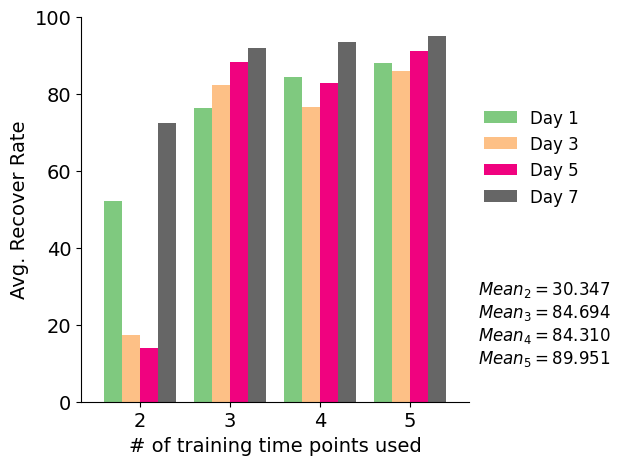

In [10]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 1', 'Day 3', 'Day 5', 'Day 7']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)
plt.savefig('./Reviewer2_Q1_12.svg', dpi=300, bbox_inches='tight', transparent=True)

### Performance of const mode with different noise levels (Cord blood)

In [2]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/CordBloodConstRates/0929_115228/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/CordBloodDynamicRates/0929_115437/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
from clonaltrans.pl import get_error_rate
mae, mean = get_error_rate('./trials/revision_1/checkpoints/SimulationsConstNoise', model_const)

mae = np.swapaxes(np.array(mae), 0, 1) # (num_trials, num_time_points, rates) -> (num_time_points, num_trials, rates)
mean = np.swapaxes(np.array(mean), 0, 1)

mae = mae.reshape(mae.shape[0], -1)
mean = np.mean(mean, axis=1)

mae = [list(mae[i]) for i in range(len(mae))]

  0%|          | 0/18 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 18/18 [01:09<00:00,  3.89s/it]


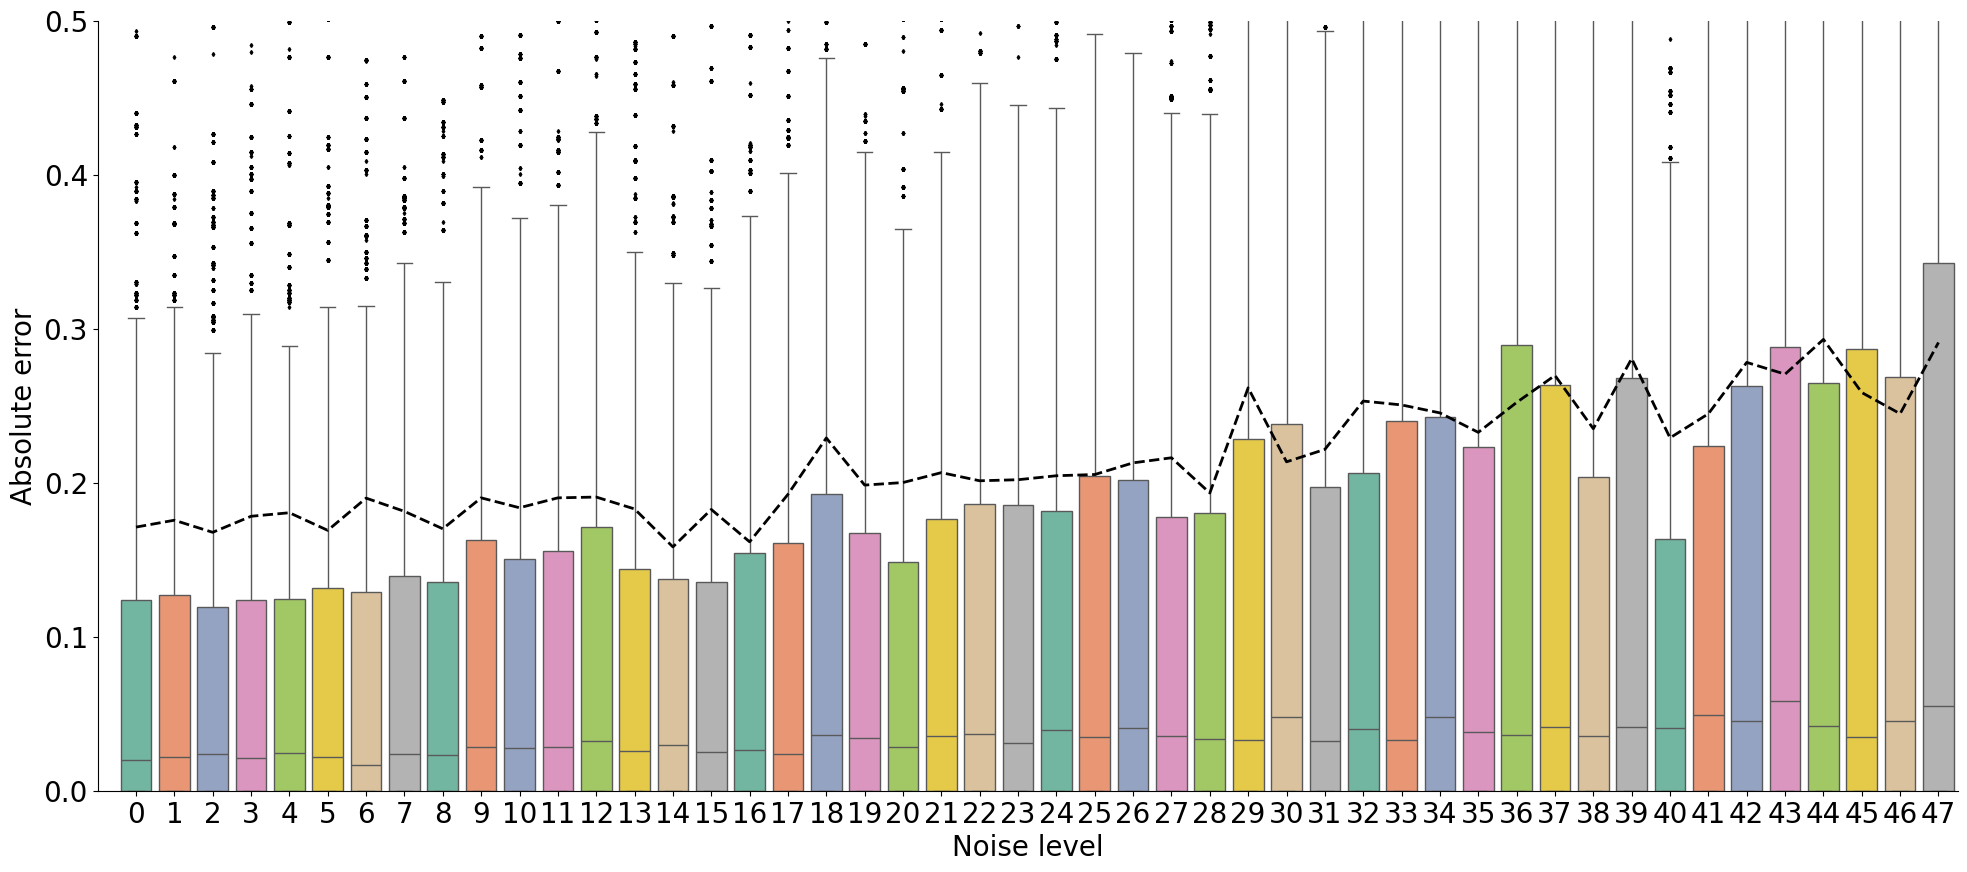

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 10))
ax = sns.boxplot(mae, palette='Set2',
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.xlabel('Noise level', fontsize=20)
plt.xticks([i for i in range(48)], [i for i in range(48)], fontsize=20)
plt.plot([i for i in range(48)], mean, color='black', linewidth=2, linestyle='dashed')
plt.ylabel('Absolute error', fontsize=20)
plt.ylim(0, 0.5)
plt.yticks([i / 10 for i in range(6)], [i / 10 for i in range(6)], fontsize=20)
plt.savefig('./Reviewer3_Q2_1.svg', dpi=300, bbox_inches='tight', transparent=True)

In [4]:
from clonaltrans.data import simulation_const

K = model_const.get_matrix_K(eval=True)

N = simulation_const(
    K,
    model_const.L.detach().cpu(),
    model_const.config,
    torch.tensor([0.0, 2.0, 5.0, 8.0, 12.0, 15.0]).to(device),
    model_const.N[0].detach().cpu()
)

In [5]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsConstNoise', 
    N, 
    valid_times=[0.0, 2.0, 5.0, 8.0, 12.0, 15.0]
)

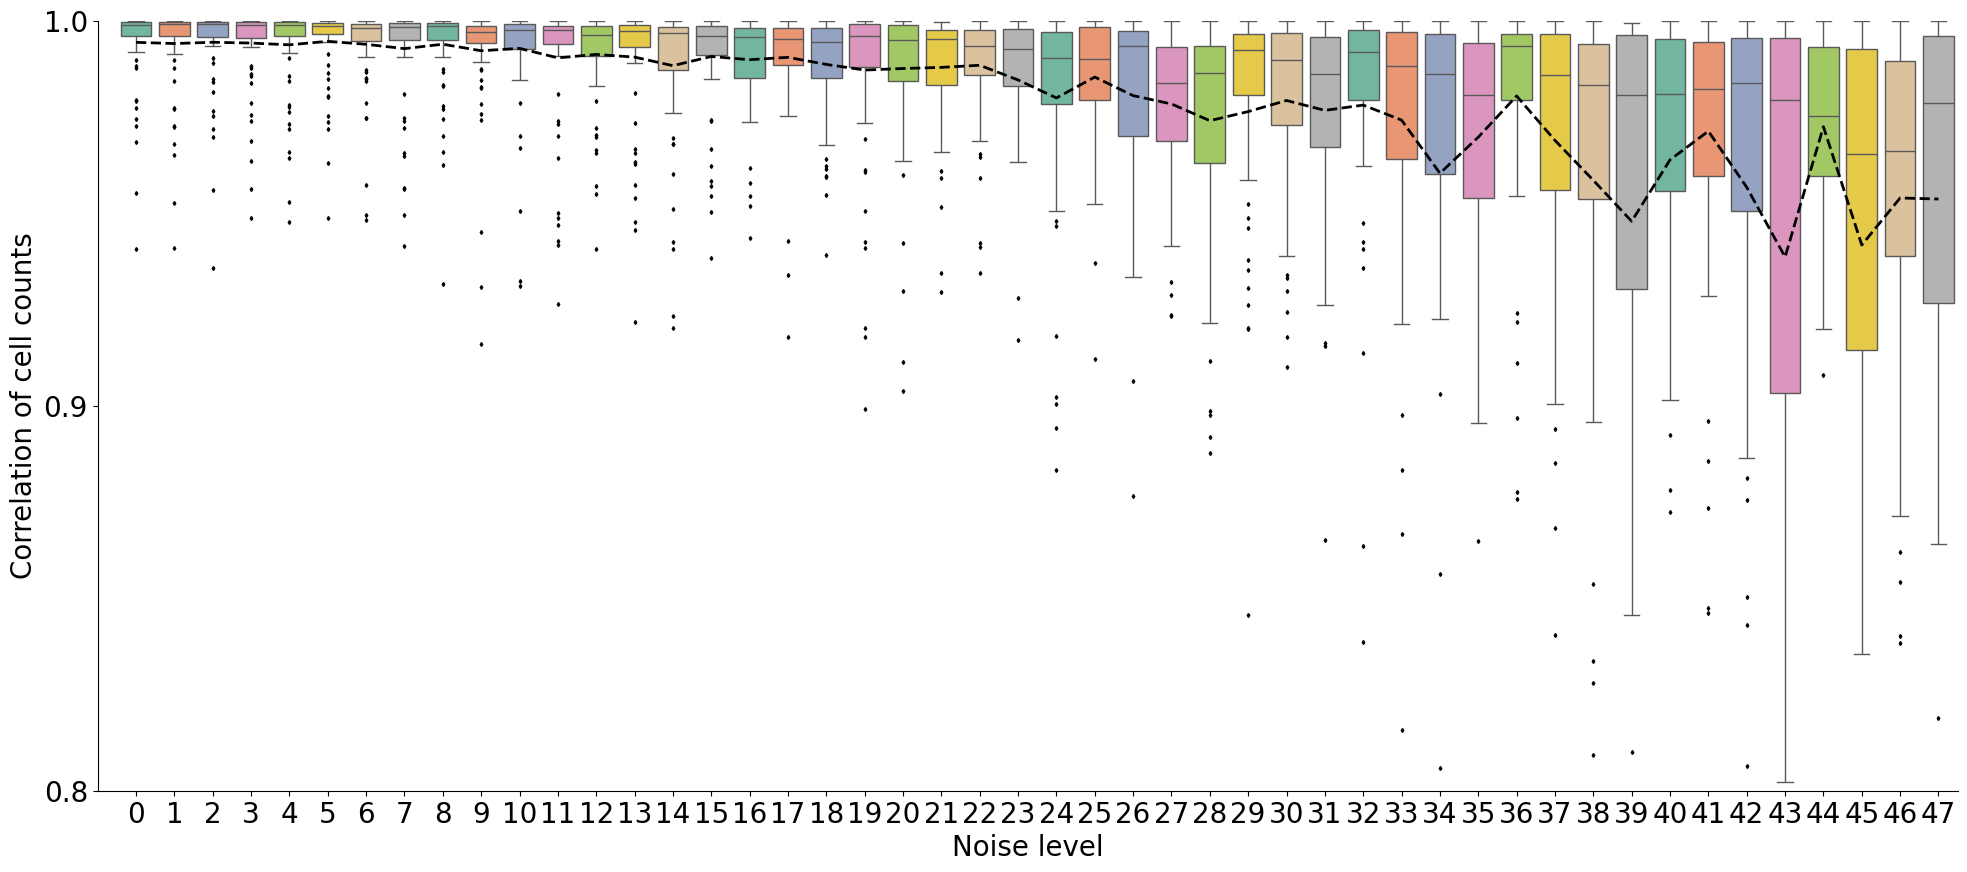

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 10))
ax = sns.boxplot(corr, palette='Set2', 
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.xlabel('Noise level', fontsize=20)
plt.xticks([i for i in range(48)], [i for i in range(48)], fontsize=20)
plt.plot([i for i in range(48)], [np.mean(corr[i]) for i in range(48)], color='black', linewidth=2, linestyle='dashed')
plt.ylabel('Correlation of cell counts', fontsize=20)
plt.ylim(0.8, 1.0)
plt.yticks([i / 10 for i in range(8, 11)], [i / 10 for i in range(8, 11)], fontsize=20)
plt.savefig('./Reviewer3_Q2_2.svg', dpi=300, bbox_inches='tight', transparent=True)

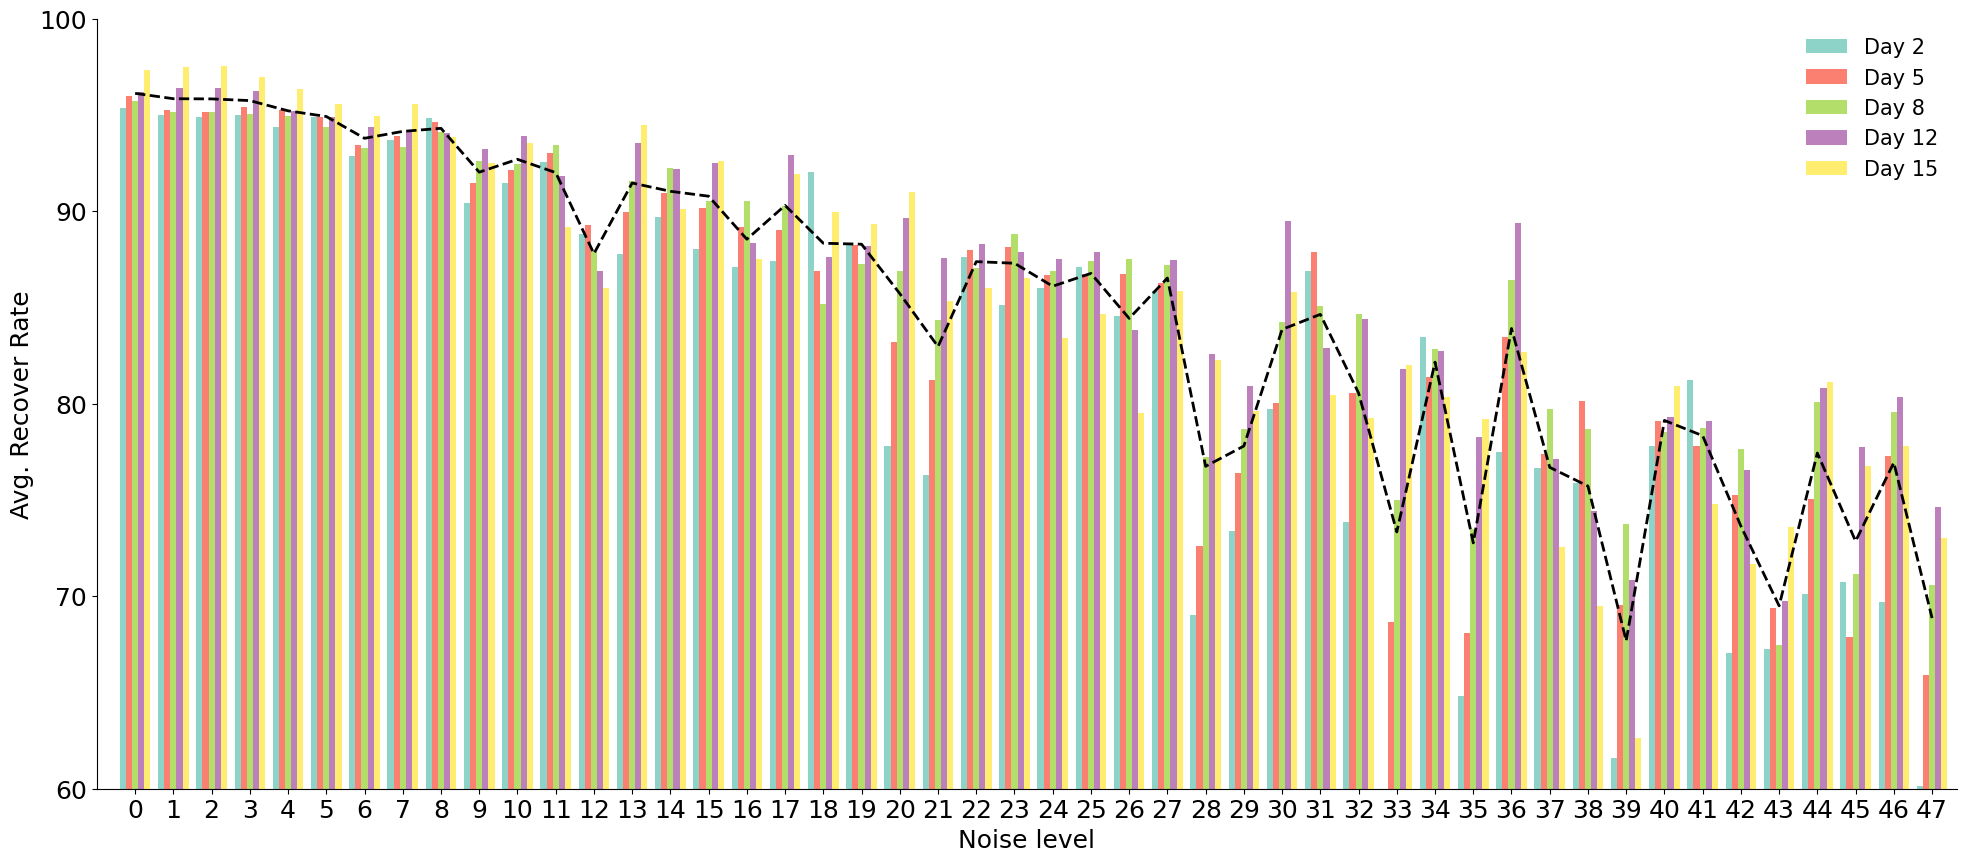

In [58]:
df = pd.DataFrame(counts)
df.index = [str(i) for i in range(48)]
df.columns = ['Day 2', 'Day 5', 'Day 8', 'Day 12', 'Day 15']

ax = df.plot(kind='bar', stacked=False, figsize=(24,10), width=0.8, colormap='Set3')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.legend(bbox_to_anchor=(1, 1), frameon=False, fontsize=15)
plt.yticks([60, 70, 80, 90, 100], [60, 70, 80, 90, 100], fontsize=18)
plt.ylabel('Avg. Recover Rate', fontsize=18)
plt.ylim(60, 100)

plt.xlabel('Noise level', fontsize=18)
plt.xticks([i for i in range(48)], [i for i in range(48)], fontsize=18, rotation=0)
plt.plot([i for i in range(48)], [np.mean(counts[i]) for i in range(48)], color='black', linewidth=2, linestyle='dashed')
plt.savefig('./Reviewer3_Q2_3.svg', dpi=300, bbox_inches='tight', transparent=True)

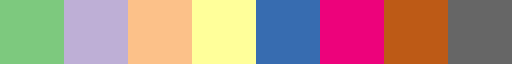

In [46]:
cmap

/tmp/ipykernel_796876/2313750776.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Accent')


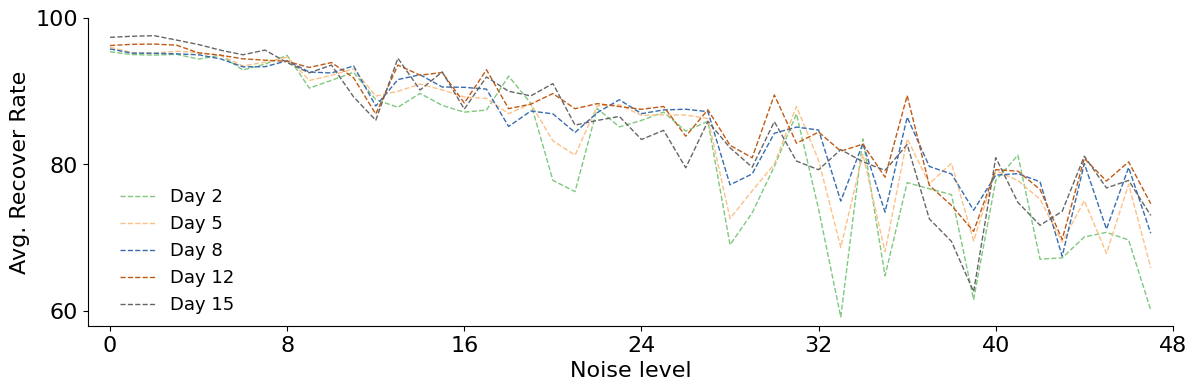

In [12]:
import matplotlib.cm as cm
cmap = cm.get_cmap('Accent')
plt.figure(figsize=(14, 4))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.yticks([40, 60, 80, 100], [40, 60, 80, 100], fontsize=16)
plt.ylabel('Avg. Recover Rate', fontsize=16)
plt.ylim(58, 100)

plt.xlabel('Noise level', fontsize=16)
plt.xticks([0, 8, 16, 24, 32, 40, 48], [0, 8, 16, 24, 32, 40, 48], fontsize=16, rotation=0)
plt.plot([i for i in range(48)], [counts[i][0] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 2', color=cmap(0))
plt.plot([i for i in range(48)], [counts[i][1] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 5', color=cmap(2))
plt.plot([i for i in range(48)], [counts[i][2] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 8', color=cmap(4))
plt.plot([i for i in range(48)], [counts[i][3] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 12', color=cmap(6))
plt.plot([i for i in range(48)], [counts[i][4] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 15', color=cmap(7))
plt.legend(bbox_to_anchor=(0.15, 0.5), frameon=False, fontsize=13)

plt.savefig('./Reviewer3_Q2_7.svg', dpi=300, bbox_inches='tight', transparent=True)

### Performance of dynamic mode with different noise levels (Mouse hematopoiesis)

In [13]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebConstRates/0929_115327/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [14]:
from clonaltrans.pl import get_error_rate
mae, mean = get_error_rate('./trials/revision_1/checkpoints/SimulationsDynamicNoise', model_dyna)

mae = np.swapaxes(np.array(mae), 0, 1) # (num_trials, num_time_points, rates) -> (num_time_points, num_trials, rates)
mean = np.swapaxes(np.array(mean), 0, 1)

mae = mae.reshape(mae.shape[0], -1)
mean = np.mean(mean, axis=1)

mae = [list(mae[i]) for i in range(len(mae))]

  0%|          | 0/7 [00:00<?, ?it/s]/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
100%|██████████| 7/7 [02:01<00:00, 17.33s/it]


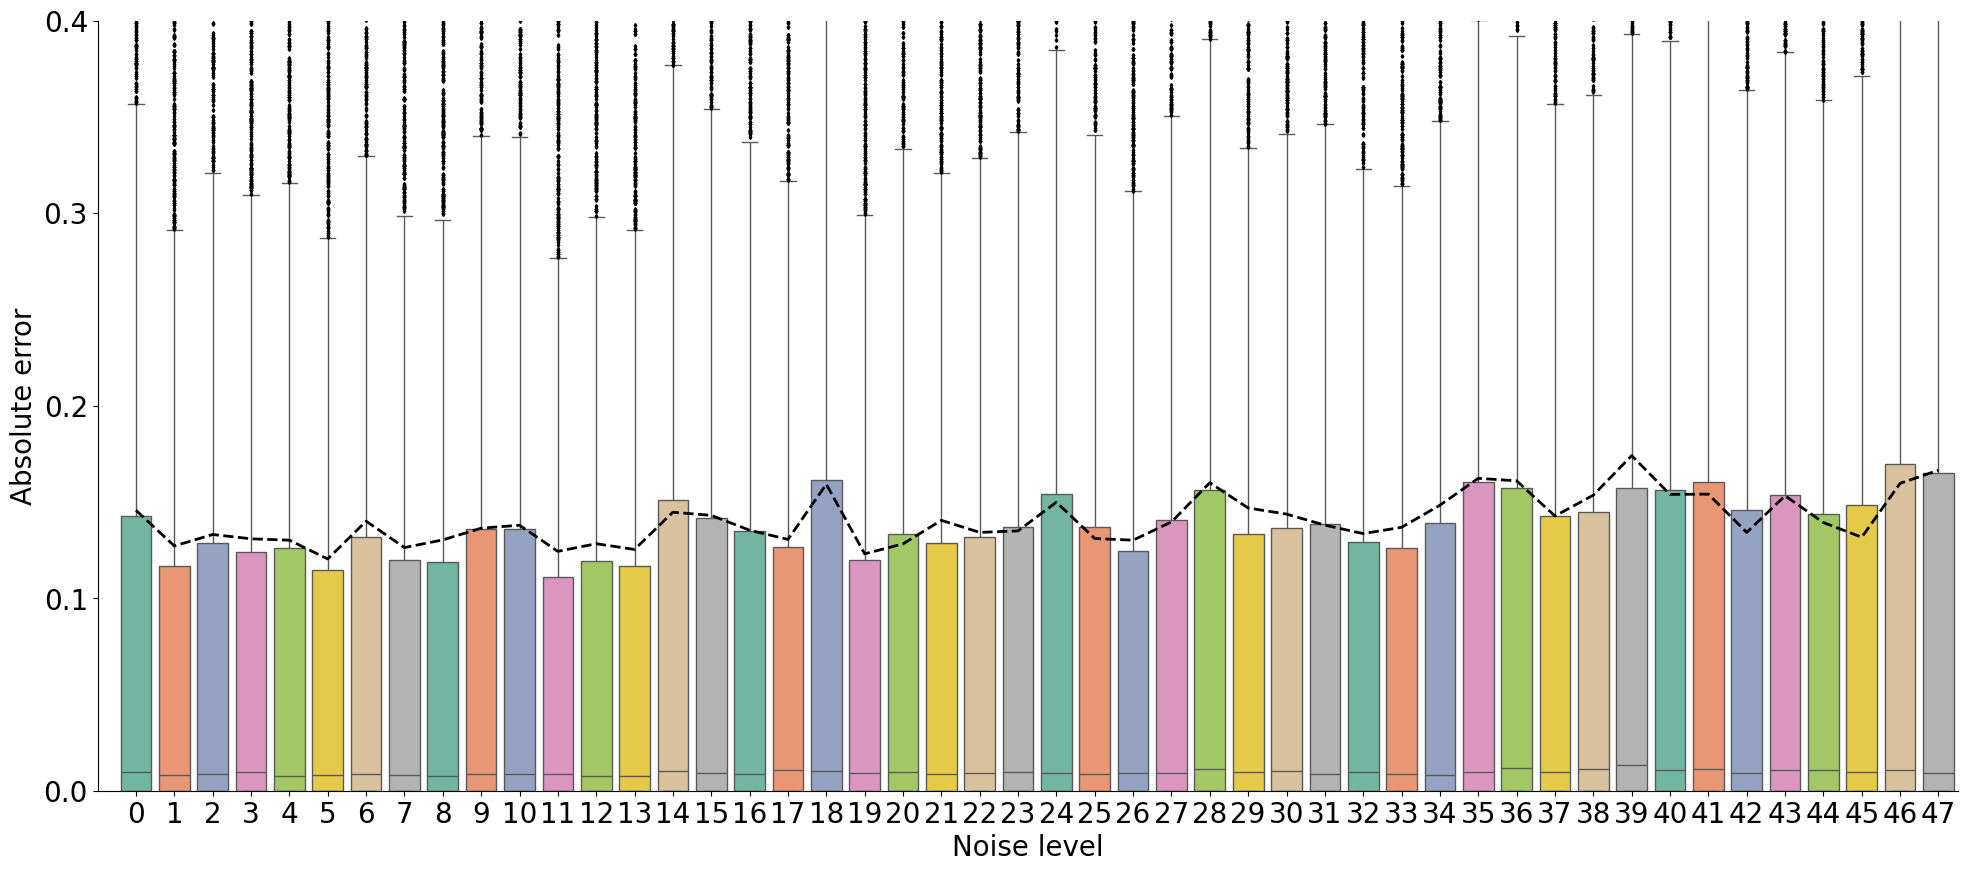

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 10))
ax = sns.boxplot(mae, palette='Set2',
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.xlabel('Noise level', fontsize=20)
plt.xticks([i for i in range(48)], [i for i in range(48)], fontsize=20)
plt.plot([i for i in range(48)], mean, color='black', linewidth=2, linestyle='dashed')
plt.ylabel('Absolute error', fontsize=20)
plt.ylim(0, 0.4)
plt.yticks([i / 10 for i in range(5)], [i / 10 for i in range(5)], fontsize=20)
plt.savefig('./Reviewer3_Q2_4.svg', dpi=300, bbox_inches='tight', transparent=True)

In [15]:
from clonaltrans.data import simulation_dyna

K1_encode = model_dyna.model.block.K1_encode.detach()
K1_decode = model_dyna.model.block.K1_decode.detach()
K2_encode = model_dyna.model.block.K2_encode.detach()
K2_decode = model_dyna.model.block.K2_decode.detach()

N = simulation_dyna(
    K1_encode, K1_decode, K2_encode, K2_decode, 
    model_dyna.L.detach().cpu(), 
    model_dyna.config,
    torch.tensor([0.0, 1.0, 3.0, 5.0, 7.0]).to(device),
    model_dyna.N[0].detach().cpu()
)

In [16]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsDynamicNoise', 
    N, 
    valid_times=[0.0, 1.0, 3.0, 5.0, 7.0]
)

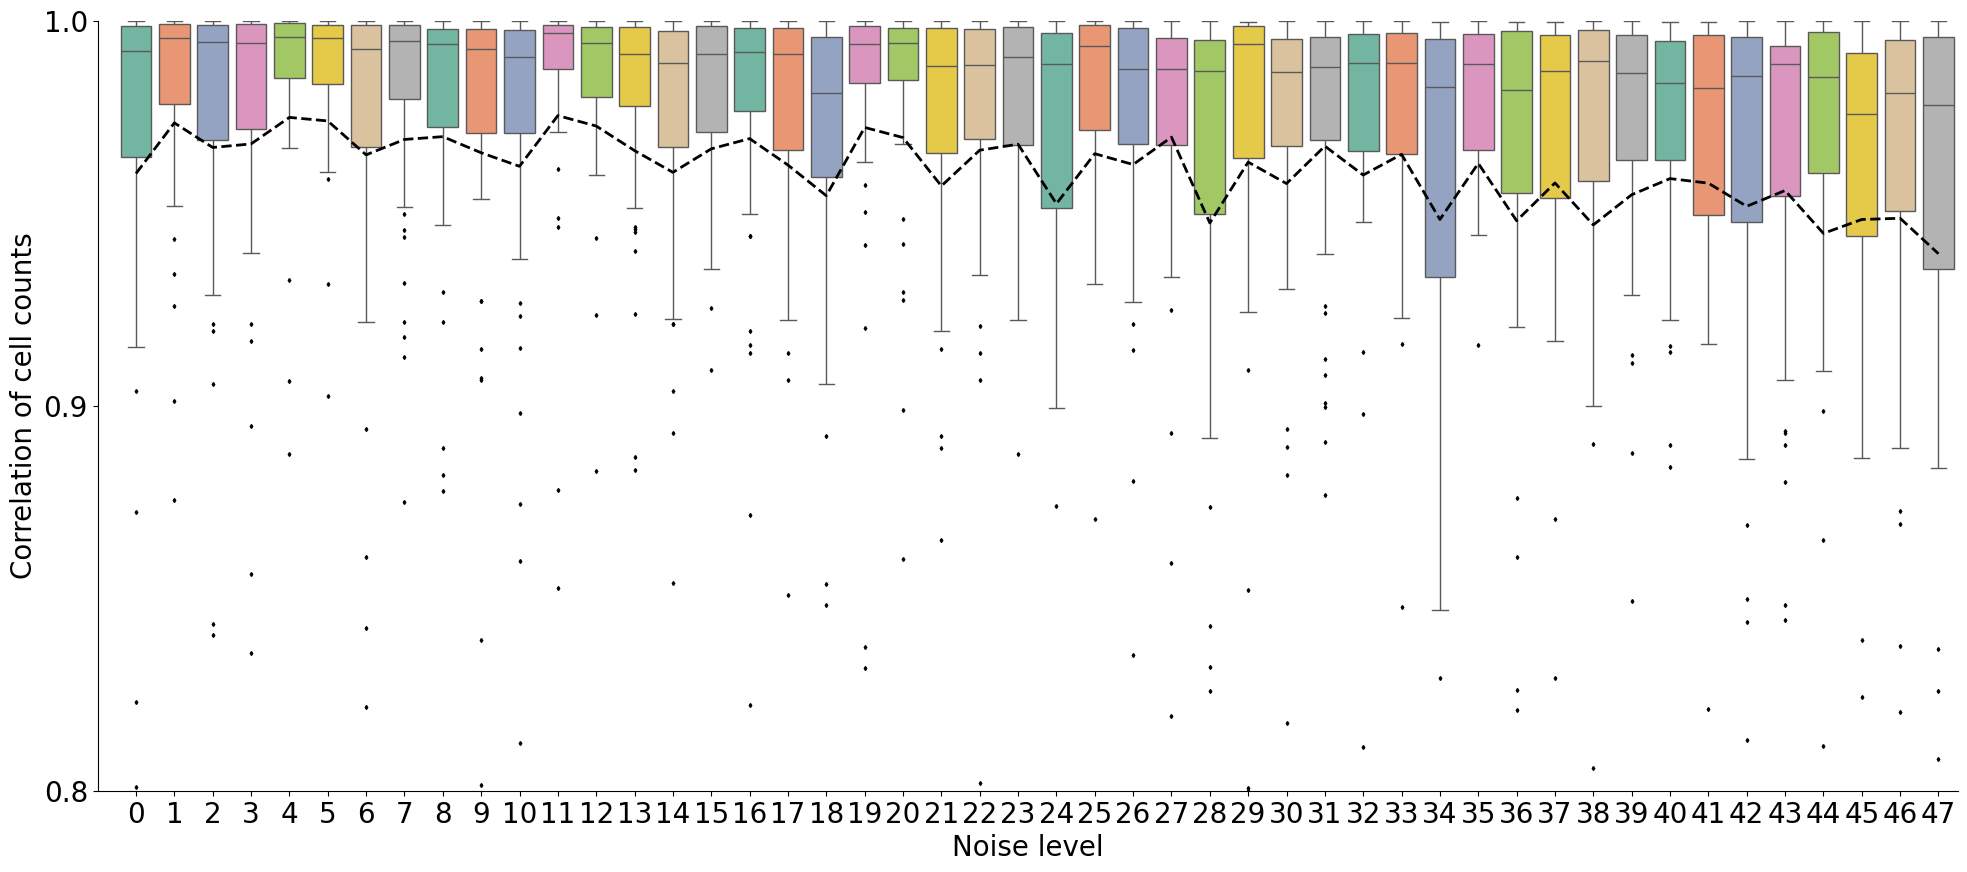

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(24, 10))
ax = sns.boxplot(corr, palette='Set2', 
    flierprops={
        'marker': 'd', 
        'markerfacecolor': 'black', 
        'markeredgecolor': 'black',
        'markersize': 2
    }
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.xlabel('Noise level', fontsize=20)
plt.xticks([i for i in range(48)], [i for i in range(48)], fontsize=20)
plt.plot([i for i in range(48)], [np.mean(corr[i]) for i in range(48)], color='black', linewidth=2, linestyle='dashed')
plt.ylabel('Correlation of cell counts', fontsize=20)
plt.ylim(0.8, 1.0)
plt.yticks([i / 10 for i in range(8, 11)], [i / 10 for i in range(8, 11)], fontsize=20)
plt.savefig('./Reviewer3_Q2_5.svg', dpi=300, bbox_inches='tight', transparent=True)

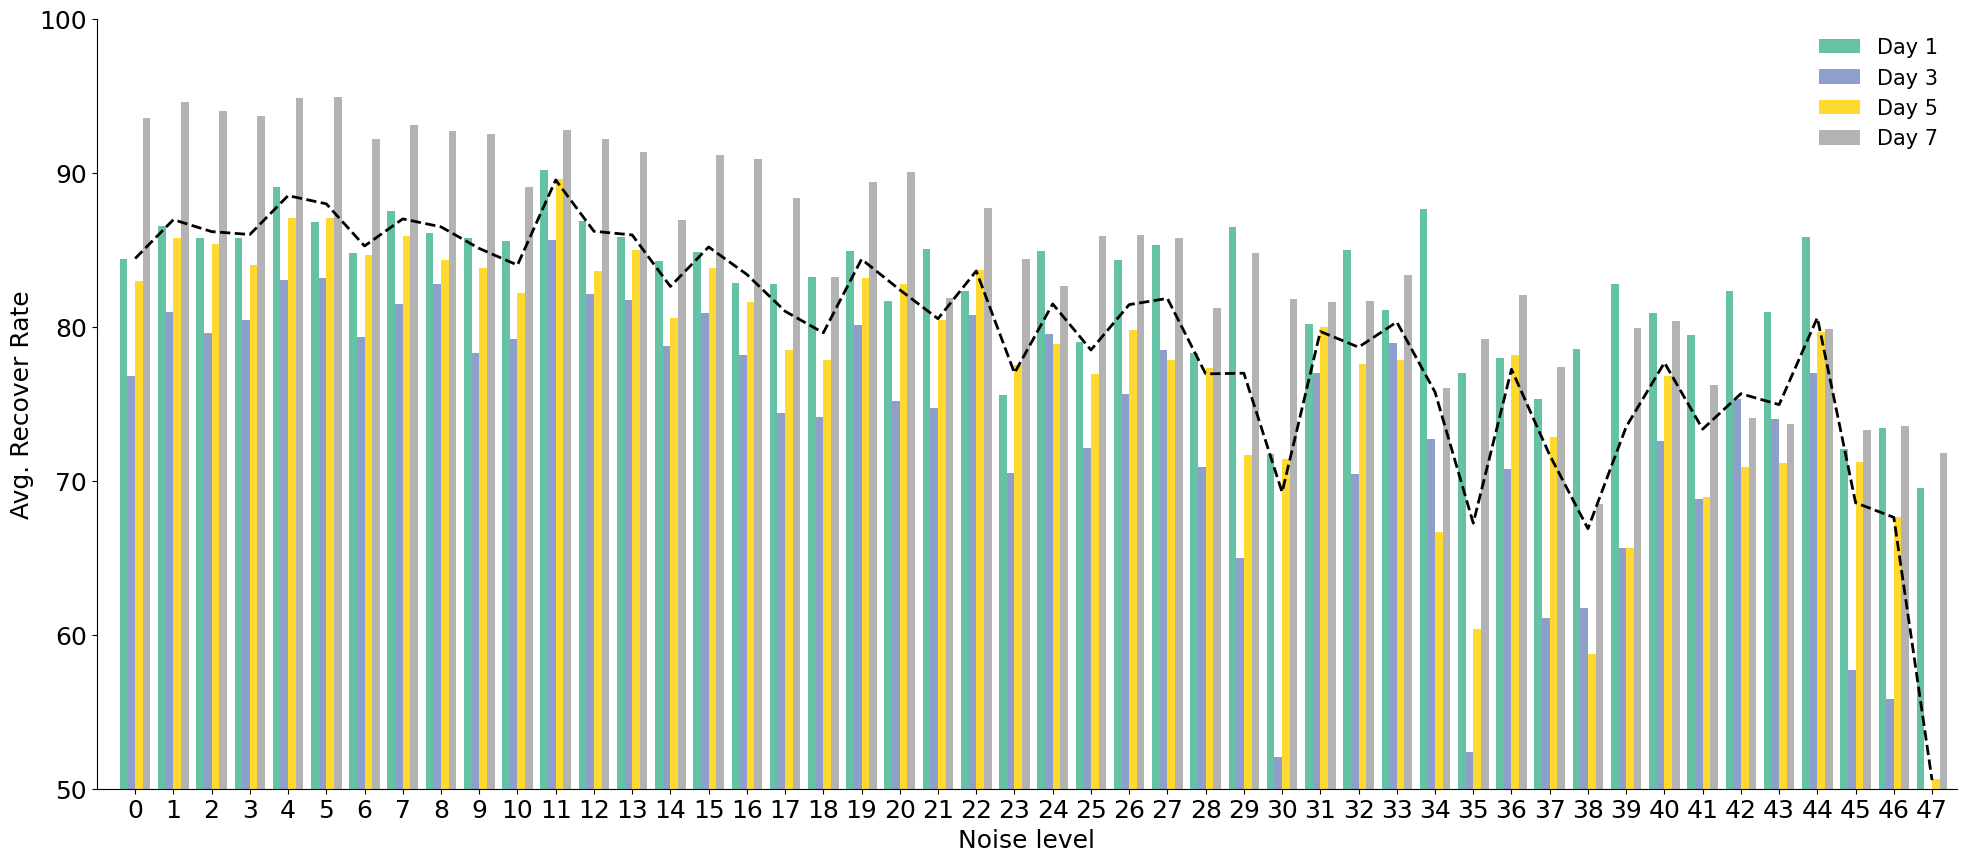

In [27]:
df = pd.DataFrame(counts)
df.index = [str(i) for i in range(48)]
df.columns = ['Day 1', 'Day 3', 'Day 5', 'Day 7']

ax = df.plot(kind='bar', stacked=False, figsize=(24,10), width=0.8, colormap='Set2')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.legend(bbox_to_anchor=(1, 1), frameon=False, fontsize=15)
plt.yticks([50, 60, 70, 80, 90, 100], [50, 60, 70, 80, 90, 100], fontsize=18)
plt.ylabel('Avg. Recover Rate', fontsize=18)
plt.ylim(50, 100)

plt.xlabel('Noise level', fontsize=18)
plt.xticks([i for i in range(48)], [i for i in range(48)], fontsize=18, rotation=0)
plt.plot([i for i in range(48)], [np.mean(counts[i]) for i in range(48)], color='black', linewidth=2, linestyle='dashed')
plt.savefig('./Reviewer3_Q2_6.svg', dpi=300, bbox_inches='tight', transparent=True)

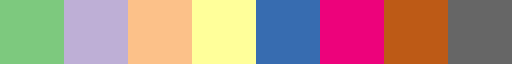

In [57]:
cmap

/tmp/ipykernel_796876/3113663204.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Accent')


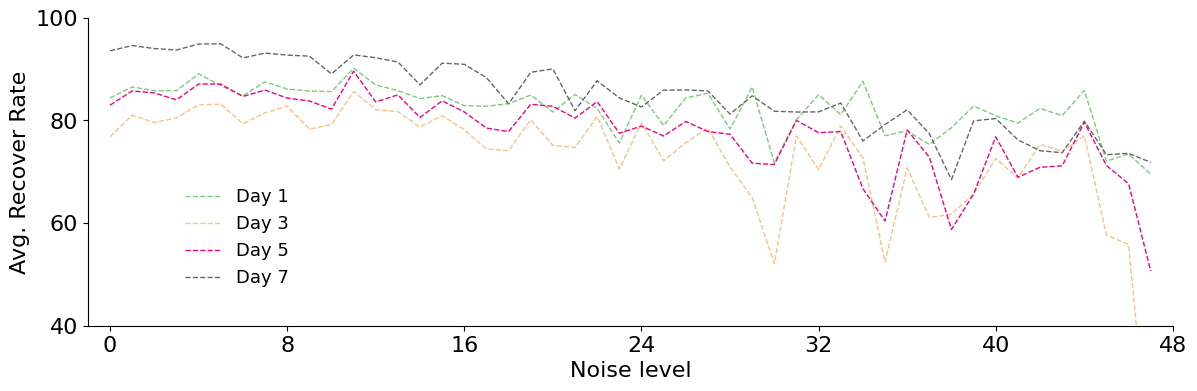

In [18]:
import matplotlib.cm as cm
cmap = cm.get_cmap('Accent')
plt.figure(figsize=(14, 4))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.yticks([40, 60, 80, 100], [40, 60, 80, 100], fontsize=16)
plt.ylabel('Avg. Recover Rate', fontsize=16)
plt.ylim(40, 100)

plt.xlabel('Noise level', fontsize=16)
plt.xticks([0, 8, 16, 24, 32, 40, 48], [0, 8, 16, 24, 32, 40, 48], fontsize=16, rotation=0)
plt.plot([i for i in range(48)], [counts[i][0] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 1', color=cmap(0))
plt.plot([i for i in range(48)], [counts[i][1] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 3', color=cmap(2))
plt.plot([i for i in range(48)], [counts[i][2] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 5', color=cmap(5))
plt.plot([i for i in range(48)], [counts[i][3] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 7', color=cmap(7))
plt.legend(bbox_to_anchor=(0.2, 0.5), frameon=False, fontsize=13)

plt.savefig('./Reviewer3_Q2_8.svg', dpi=300, bbox_inches='tight', transparent=True)